In [2]:
import zipfile
from pathlib import Path
import pandas as pd

In [3]:
zip_path = Path(r"C:\Users\shiva\Downloads\archive.zip")

# Folder where extracted Excel files will go
extract_folder = Path("olist_excel")
extract_folder.mkdir(exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [4]:
for file in extract_folder.rglob("*"):
    if file.is_file():
        print(file)

olist_excel\olist_analysis.db
olist_excel\olist_customers_dataset.csv
olist_excel\olist_geolocation_dataset.csv
olist_excel\olist_orders_dataset.csv
olist_excel\olist_order_items_dataset.csv
olist_excel\olist_order_payments_dataset.csv
olist_excel\olist_order_reviews_dataset.csv
olist_excel\olist_products_dataset.csv
olist_excel\olist_sellers_dataset.csv
olist_excel\product_category_name_translation.csv


In [5]:
files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv"
}
dfs = {name: pd.read_csv(extract_folder / filename) for name, filename in files.items()}

for name, df in dfs.items():
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print("Data Types:")
    print(df.dtypes)


=== customers ===
Shape: (99441, 5)
Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

=== geolocation ===
Shape: (1000163, 5)
Data Types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

=== orders ===
Shape: (99441, 8)
Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

=== order_items ===
Shape: (112650, 7)
Data Types:
order_id                object
order_item_id            int64
produc

In [6]:
for name, df in dfs.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    null_count = df.isnull().sum()

    audit = pd.DataFrame({
        "Data Type": df.dtypes,
        "Null Count": null_count,
        "Null %": (null_count / len(df) * 100).round(2),
        "Unique Values": df.nunique()
    })

    print(audit)


customers
                         Data Type  Null Count  Null %  Unique Values
customer_id                 object           0     0.0          99441
customer_unique_id          object           0     0.0          96096
customer_zip_code_prefix     int64           0     0.0          14994
customer_city               object           0     0.0           4119
customer_state              object           0     0.0             27

geolocation
                            Data Type  Null Count  Null %  Unique Values
geolocation_zip_code_prefix     int64           0     0.0          19015
geolocation_lat               float64           0     0.0         717360
geolocation_lng               float64           0     0.0         717613
geolocation_city               object           0     0.0           8011
geolocation_state              object           0     0.0             27

orders
                              Data Type  Null Count  Null %  Unique Values
order_id                         ob

In [7]:
# order status breakdown
print("Order status breakdown:")
print(dfs["orders"]["order_status"].value_counts())

# do null delivery dates line up with non-delivered statuses?
null_delivery = dfs["orders"][dfs["orders"]["order_delivered_customer_date"].isnull()]
print("\nStatus breakdown among orders with NULL delivered_customer_date:")
print(null_delivery["order_status"].value_counts())

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Status breakdown among orders with NULL delivered_customer_date:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [8]:
for name, df in dfs.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print("Rows:", len(df))
    print("Columns:")
    print(list(df.columns))


customers
Rows: 99441
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

geolocation
Rows: 1000163
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

orders
Rows: 99441
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

order_items
Rows: 112650
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

payments
Rows: 103886
Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

reviews
Rows: 99224
Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

products
Rows: 32951
Columns:
['product_id', 'product_categor

In [9]:
delivered_missing_date = dfs["orders"][
    (dfs["orders"]["order_status"] == "delivered") &
    (dfs["orders"]["order_delivered_customer_date"].isnull())
]

print(delivered_missing_date)

                               order_id                       customer_id  \
3002   2d1e2d5bf4dc7227b3bfebb81328c15f  ec05a6d8558c6455f0cbbd8a420ad34f   
20618  f5dd62b788049ad9fc0526e3ad11a097  5e89028e024b381dc84a13a3570decb4   
43834  2ebdfc4f15f23b91474edf87475f108e  29f0540231702fda0cfdee0a310f11aa   
79263  e69f75a717d64fc5ecdfae42b2e8e086  cfda40ca8dd0a5d486a9635b611b398a   
82868  0d3268bad9b086af767785e3f0fc0133  4f1d63d35fb7c8999853b2699f5c7649   
92643  2d858f451373b04fb5c984a1cc2defaf  e08caf668d499a6d643dafd7c5cc498a   
97647  ab7c89dc1bf4a1ead9d6ec1ec8968a84  dd1b84a7286eb4524d52af4256c0ba24   
98038  20edc82cf5400ce95e1afacc25798b31  28c37425f1127d887d7337f284080a0f   

      order_status order_purchase_timestamp    order_approved_at  \
3002     delivered      2017-11-28 17:44:07  2017-11-28 17:56:40   
20618    delivered      2018-06-20 06:58:43  2018-06-20 07:19:05   
43834    delivered      2018-07-01 17:05:11  2018-07-01 17:15:12   
79263    delivered      2018-07-01

In [10]:
for name, df in dfs.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    for col in df.columns:
        if "id" in col.lower():
            print(
                f"{col}: "
                f"{df[col].nunique():,} unique values "
                f"out of {len(df):,} rows"
            )


customers
customer_id: 99,441 unique values out of 99,441 rows
customer_unique_id: 96,096 unique values out of 99,441 rows

geolocation

orders
order_id: 99,441 unique values out of 99,441 rows
customer_id: 99,441 unique values out of 99,441 rows

order_items
order_id: 98,666 unique values out of 112,650 rows
order_item_id: 21 unique values out of 112,650 rows
product_id: 32,951 unique values out of 112,650 rows
seller_id: 3,095 unique values out of 112,650 rows

payments
order_id: 99,440 unique values out of 103,886 rows

reviews
review_id: 98,410 unique values out of 99,224 rows
order_id: 98,673 unique values out of 99,224 rows

products
product_id: 32,951 unique values out of 32,951 rows
product_width_cm: 95 unique values out of 32,951 rows

sellers
seller_id: 3,095 unique values out of 3,095 rows

category_translation


In [11]:
customers = dfs["customers"]

print("Total customer records:", len(customers))
print("Unique customer_id:", customers["customer_id"].nunique())
print("Unique customer_unique_id:", customers["customer_unique_id"].nunique())

print("\nCustomer IDs appearing more than once:")
print(
    customers["customer_unique_id"]
    .value_counts()
    .loc[lambda x: x > 1]
    .head(10)
)

Total customer records: 99441
Unique customer_id: 99441
Unique customer_unique_id: 96096

Customer IDs appearing more than once:
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
63cfc61cee11cbe306bff5857d00bfe4     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
de34b16117594161a6a89c50b289d35a     6
dc813062e0fc23409cd255f7f53c7074     6
Name: count, dtype: int64


In [12]:
customer_id_check = customers[
    customers["customer_unique_id"] == "8d50f5eadf50201ccdcedfb9e2ac8455"
]

print(customer_id_check)

                            customer_id                customer_unique_id  \
14186  1bd3585471932167ab72a84955ebefea  8d50f5eadf50201ccdcedfb9e2ac8455   
15321  a8fabc805e9a10a3c93ae5bff642b86b  8d50f5eadf50201ccdcedfb9e2ac8455   
16654  897b7f72042714efaa64ac306ba0cafc  8d50f5eadf50201ccdcedfb9e2ac8455   
36122  b2b13de0770e06de50080fea77c459e6  8d50f5eadf50201ccdcedfb9e2ac8455   
38073  42dbc1ad9d560637c9c4c1533746f86d  8d50f5eadf50201ccdcedfb9e2ac8455   
40141  dfb941d6f7b02f57a44c3b7c3fefb44b  8d50f5eadf50201ccdcedfb9e2ac8455   
48614  65f9db9dd07a4e79b625effa4c868fcb  8d50f5eadf50201ccdcedfb9e2ac8455   
52574  1c62b48fb34ee043310dcb233caabd2e  8d50f5eadf50201ccdcedfb9e2ac8455   
58707  a682769c4bc10fc6ef2101337a6c83c9  8d50f5eadf50201ccdcedfb9e2ac8455   
67996  6289b75219d757a56c0cce8d9e427900  8d50f5eadf50201ccdcedfb9e2ac8455   
72745  3414a9c813e3ca02504b8be8b2deb27f  8d50f5eadf50201ccdcedfb9e2ac8455   
74510  0e4fdc084a6b9329ed55d62dcd653ccf  8d50f5eadf50201ccdcedfb9e2ac8455   

In [13]:
order_items = dfs["order_items"]

items_per_order = order_items.groupby("order_id").size()

print("Orders with items:", len(items_per_order))
print("\nItems per order:")
print(items_per_order.describe())

print("\nOrders with the most items:")
print(items_per_order.sort_values(ascending=False).head(10))

Orders with items: 98666

Items per order:
count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

Orders with the most items:
order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
2c2a19b5703863c908512d135aa6accc    12
c05d6a79e55da72ca780ce90364abed9    12
dtype: int64


In [14]:
orders = dfs["orders"]
order_items = dfs["order_items"]

orders_with_items = order_items["order_id"].unique()

orders_without_items = orders[
    ~orders["order_id"].isin(orders_with_items)
]

print("Orders without item records:", len(orders_without_items))

print("\nStatus breakdown:")
print(orders_without_items["order_status"].value_counts())

Orders without item records: 775

Status breakdown:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [15]:
payments = dfs["payments"]

payments_per_order = payments.groupby("order_id").size()

print("Orders with payment records:", len(payments_per_order))

print("\nPayment records per order:")
print(payments_per_order.describe())

print("\nOrders with the most payment records:")
print(payments_per_order.sort_values(ascending=False).head(10))

Orders with payment records: 99440

Payment records per order:
count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

Orders with the most payment records:
order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
ee9ca989fc93ba09a6eddc250ce01742    19
4bfcba9e084f46c8e3cb49b0fa6e6159    15
21577126c19bf11a0b91592e5844ba78    15
3c58bffb70dcf45f12bdf66a3c215905    14
4689b1816de42507a7d63a4617383c59    14
dtype: int64


In [16]:
print("Payment types:")
print(payments["payment_type"].value_counts())

print("\nPayment installments:")
print(payments["payment_installments"].describe())

print("\nPayment value:")
print(payments["payment_value"].describe())

Payment types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Payment installments:
count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

Payment value:
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


In [17]:
print("not_defined payments:")
print(
    payments[payments["payment_type"] == "not_defined"]
)

print("\nZero-value payments:")
print(
    payments[payments["payment_value"] == 0]
)

not_defined payments:
                               order_id  payment_sequential payment_type  \
51280  4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411  00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
94427  c8c528189310eaa44a745b8d9d26908b                   1  not_defined   

       payment_installments  payment_value  
51280                     1            0.0  
57411                     1            0.0  
94427                     1            0.0  

Zero-value payments:
                                order_id  payment_sequential payment_type  \
19922   8bcbe01d44d147f901cd3192671144db                   4      voucher   
36822   fa65dad1b0e818e3ccc5cb0e39231352                  14      voucher   
43744   6ccb433e00daae1283ccc956189c82ae                   4      voucher   
51280   4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411   00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
62674   4

In [18]:
reviews = dfs["reviews"]

print("Review score distribution:")
print(reviews["review_score"].value_counts().sort_index())

print("\nReview score statistics:")
print(reviews["review_score"].describe())

print("\nReviews per order:")
reviews_per_order = reviews.groupby("order_id").size()
print(reviews_per_order.describe())

print("\nOrders with multiple reviews:")
print(reviews_per_order[reviews_per_order > 1].head(10))

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Review score statistics:
count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

Reviews per order:
count    98673.000000
mean         1.005584
std          0.075060
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
dtype: float64

Orders with multiple reviews:
order_id
0035246a40f520710769010f752e7507    2
013056cfe49763c6f66bda03396c5ee3    2
0176a6846bcb3b0d3aa3116a9a768597    2
02355020fd0a40a0d56df9f6ff060413    2
029863af4b968de1e5d6a82782e662f5    2
02e0b68852217f5715fb9cc885829454    2
02e723e8edb4a123d414f56cc9c4665e    2
03515a836bb855b03f7df9dee520a8fc    2
03c939fd7fd3b38f8485a0f95798f1f6    3
03eba6d9fef8f5b3e811d4b5a7cca9cd    2
dtype: int6

In [19]:
products = dfs["products"]

print("Product rows:", len(products))

print("\nMissing values:")
print(products.isnull().sum())

print("\nUnique products:", products["product_id"].nunique())

print("\nNumber of unique categories:",
      products["product_category_name"].nunique())

Product rows: 32951

Missing values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Unique products: 32951

Number of unique categories: 73


In [20]:
missing_category_products = products[
    products["product_category_name"].isnull()
]

print("Products missing category:",
      len(missing_category_products))

print("\nMissing-category product IDs that appear in order_items:")

print(
    order_items[
        order_items["product_id"].isin(
            missing_category_products["product_id"]
        )
    ]["product_id"].nunique()
)

Products missing category: 610

Missing-category product IDs that appear in order_items:
610


In [21]:
sellers = dfs["sellers"]

print("Seller rows:", len(sellers))

print("\nMissing values:")
print(sellers.isnull().sum())

print("\nUnique sellers:", sellers["seller_id"].nunique())

print("\nSeller states:")
print(sellers["seller_state"].value_counts().head(10))

Seller rows: 3095

Missing values:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Unique sellers: 3095

Seller states:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


In [22]:
geo = dfs["geolocation"]

print("Rows:", len(geo))

print("\nUnique ZIP code prefixes:",
      geo["geolocation_zip_code_prefix"].nunique())

print("\nDuplicate rows:",
      geo.duplicated().sum())

print("\nRows per ZIP code prefix:")
print(
    geo.groupby("geolocation_zip_code_prefix")
       .size()
       .describe()
)

Rows: 1000163

Unique ZIP code prefixes: 19015

Duplicate rows: 261831

Rows per ZIP code prefix:
count    19015.000000
mean        52.598633
std         72.057907
min          1.000000
25%         10.000000
50%         29.000000
75%         66.500000
max       1146.000000
dtype: float64


In [23]:
categories = dfs["category_translation"]

print("Rows:", len(categories))

print("\nUnique Portuguese categories:",
      categories["product_category_name"].nunique())

print("Unique English categories:",
      categories["product_category_name_english"].nunique())

print("\nSample:")
print(categories.head(10))

Rows: 71

Unique Portuguese categories: 71
Unique English categories: 71

Sample:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
5           esporte_lazer                sports_leisure
6              perfumaria                     perfumery
7   utilidades_domesticas                    housewares
8               telefonia                     telephony
9      relogios_presentes                 watches_gifts


In [24]:
orders = dfs["orders"]
customers = dfs["customers"]

missing_customers = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
]

print("Orders with customer_id not found in customers:",
      len(missing_customers))

Orders with customer_id not found in customers: 0


In [25]:
order_items = dfs["order_items"]
products = dfs["products"]

missing_products = order_items[
    ~order_items["product_id"].isin(products["product_id"])
]

print(
    "Order items with product_id not found in products:",
    len(missing_products)
)

Order items with product_id not found in products: 0


In [26]:
sellers = dfs["sellers"]

missing_sellers = order_items[
    ~order_items["seller_id"].isin(sellers["seller_id"])
]

print(
    "Order items with seller_id not found in sellers:",
    len(missing_sellers)
)

Order items with seller_id not found in sellers: 0


In [27]:
payments = dfs["payments"]

payment_order_ids = payments["order_id"].unique()

orders_without_payment = orders[
    ~orders["order_id"].isin(payment_order_ids)
]

print("Orders without payment records:", len(orders_without_payment))

print("\nDetails:")
print(orders_without_payment)

Orders without payment records: 1

Details:
                               order_id                       customer_id  \
30710  bfbd0f9bdef84302105ad712db648a6c  86dc2ffce2dfff336de2f386a786e574   

      order_status order_purchase_timestamp    order_approved_at  \
30710    delivered      2016-09-15 12:16:38  2016-09-15 12:16:38   

      order_delivered_carrier_date order_delivered_customer_date  \
30710          2016-11-07 17:11:53           2016-11-09 07:47:38   

      order_estimated_delivery_date  
30710           2016-10-04 00:00:00  


In [28]:
reviews = dfs["reviews"]

missing_review_orders = reviews[
    ~reviews["order_id"].isin(orders["order_id"])
]

print(
    "Reviews with order_id not found in orders:",
    len(missing_review_orders)
)


Reviews with order_id not found in orders: 0


In [29]:
print("Order purchase date range:")

print(
    "Start:",
    orders["order_purchase_timestamp"].min()
)

print(
    "End:",
    orders["order_purchase_timestamp"].max()
)

Order purchase date range:
Start: 2016-09-04 21:15:19
End: 2018-10-17 17:30:18


In [30]:
print("Order date column types:")
print(
    orders[
        [
            "order_purchase_timestamp",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ].dtypes
)

Order date column types:
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [31]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [32]:
for col in date_columns:
    print(
        f"{col}: "
        f"{orders[col].min()}  →  {orders[col].max()}"
    )

order_purchase_timestamp: 2016-09-04 21:15:19  →  2018-10-17 17:30:18
order_approved_at: 2016-09-15 12:16:38  →  2018-09-03 17:40:06
order_delivered_carrier_date: 2016-10-08 10:34:01  →  2018-09-11 19:48:28
order_delivered_customer_date: 2016-10-11 13:46:32  →  2018-10-17 13:22:46
order_estimated_delivery_date: 2016-09-30 00:00:00  →  2018-11-12 00:00:00


In [33]:
print("Approved before purchase:",
      (orders["order_approved_at"] < orders["order_purchase_timestamp"]).sum())

print("Carrier before purchase:",
      (orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"]).sum())

print("Customer delivery before purchase:",
      (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]).sum())

print("Customer delivery before carrier:",
      (orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]).sum())

Approved before purchase: 0
Carrier before purchase: 166
Customer delivery before purchase: 0
Customer delivery before carrier: 23


In [34]:
carrier_before_purchase = orders[
    orders["order_delivered_carrier_date"]
    < orders["order_purchase_timestamp"]
].copy()

carrier_before_purchase["difference_hours"] = (
    carrier_before_purchase["order_purchase_timestamp"]
    - carrier_before_purchase["order_delivered_carrier_date"]
).dt.total_seconds() / 3600

print(carrier_before_purchase["difference_hours"].describe())

count     166.000000
mean       26.039478
std       318.923845
min         0.006667
25%         0.234444
50%         0.599861
75%         1.017500
max      4109.098056
Name: difference_hours, dtype: float64


In [35]:
print(
    carrier_before_purchase[
        [
            "order_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_carrier_date",
            "difference_hours"
        ]
    ]
    .sort_values("difference_hours", ascending=False)
    .head(10)
)

                               order_id order_status order_purchase_timestamp  \
25883  7c48bb55e8e4f7e56d412e9653db37bc    delivered      2018-07-16 18:40:53   
83321  4021cd7611d6d9ce5ffcd24817fc374f    delivered      2018-08-18 11:49:40   
67844  db090a16182b263b1e896bb26c6f66cf    delivered      2018-07-13 16:14:08   
65452  9711d975b961355b4b5d636857e48498    delivered      2018-06-13 15:23:50   
79401  89d32b64af005178b318f76cd60f2c3c    delivered      2018-07-06 11:54:40   
13969  6192897f85cb2aff6dd1fca56fddb45e    delivered      2018-07-18 13:34:22   
43657  3ed559dec69ab96d9074fedaf18650eb    delivered      2018-06-15 13:20:09   
4256   4e157a36ea9cf89bde6fff57a780b525    delivered      2018-08-24 14:37:50   
74503  119060af27b04f5fae8b2b0e27eef7f9    delivered      2018-06-11 14:34:47   
21910  e23c9dcc304042fa90d538be679fa68d    delivered      2018-06-13 11:41:23   

      order_delivered_carrier_date  difference_hours  
25883          2018-01-26 13:35:00       4109.098056 

In [36]:
bins = [-float("inf"), 1, 24, 24 * 7, float("inf")]
labels = [
    "< 1 hour",
    "1–24 hours",
    "1–7 days",
    "> 7 days"
]

carrier_before_purchase["severity"] = pd.cut(
    carrier_before_purchase["difference_hours"],
    bins=bins,
    labels=labels
)

print(
    carrier_before_purchase["severity"]
    .value_counts()
    .sort_index()
)

severity
< 1 hour      121
1–24 hours     43
1–7 days        1
> 7 days        1
Name: count, dtype: int64


In [37]:
delivery_before_carrier = orders[
    orders["order_delivered_customer_date"]
    < orders["order_delivered_carrier_date"]
].copy()

delivery_before_carrier["difference_hours"] = (
    delivery_before_carrier["order_delivered_carrier_date"]
    - delivery_before_carrier["order_delivered_customer_date"]
).dt.total_seconds() / 3600

print(delivery_before_carrier["difference_hours"].describe())

count     23.000000
mean      78.455133
std       89.308070
min        0.388333
25%       23.338333
50%       39.864444
75%      128.759028
max      386.308056
Name: difference_hours, dtype: float64


In [38]:
delivered_orders = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

delivered_orders["delivery_difference_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

print(delivered_orders["delivery_difference_days"].describe())

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_difference_days, dtype: float64


In [39]:
delivered_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

delivered_orders["delivery_difference_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

print("Delivered orders with actual delivery date:",
      len(delivered_orders))

print("\nDelivery difference:")
print(delivered_orders["delivery_difference_days"].describe())

Delivered orders with actual delivery date: 96470

Delivery difference:
count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_difference_days, dtype: float64


In [40]:
reviews = dfs["reviews"]

print("Review score distribution:")
print(reviews["review_score"].value_counts().sort_index())

print("\nReview score statistics:")
print(reviews["review_score"].describe())

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Review score statistics:
count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64


In [41]:
reviews_per_order = reviews.groupby("order_id").size()

print("Orders with reviews:", len(reviews_per_order))

print("\nReviews per order:")
print(reviews_per_order.describe())

print("\nOrders with multiple reviews:")
print(
    reviews_per_order[reviews_per_order > 1]
    .sort_values(ascending=False)
    .head(10)
)

Orders with reviews: 98673

Reviews per order:
count    98673.000000
mean         1.005584
std          0.075060
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
dtype: float64

Orders with multiple reviews:
order_id
df56136b8031ecd28e200bb18e6ddb2e    3
c88b1d1b157a9999ce368f218a407141    3
8e17072ec97ce29f0e1f111e598b0c85    3
03c939fd7fd3b38f8485a0f95798f1f6    3
a5507507d82c1fb664405882ed065af0    2
a17af8e6044c5ccaa87b1d97559dc554    2
a1b8aea9fd9e26a8644a65e1aaea8740    2
a1d50a1883814a31c8629adf354c1013    2
a47bf2de96db0109440cc21208edcc4f    2
a4b276bd4a9eba543ec90cdf29a67308    2
dtype: int64


In [42]:
print("Missing review titles:")
print(
    reviews["review_comment_title"].isna().sum(),
    "(",
    round(reviews["review_comment_title"].isna().mean() * 100, 2),
    "%)"
)

print("\nMissing review messages:")
print(
    reviews["review_comment_message"].isna().sum(),
    "(",
    round(reviews["review_comment_message"].isna().mean() * 100, 2),
    "%)"
)

Missing review titles:
87656 ( 88.34 %)

Missing review messages:
58247 ( 58.7 %)


In [43]:
dfs_raw = {name: df.copy() for name, df in dfs.items()}

print("Raw backup created.")

Raw backup created.


In [44]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    dfs["orders"][col] = pd.to_datetime(
        dfs["orders"][col],
        errors="coerce"
    )

print(dfs["orders"][date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [45]:
for col in date_columns:
    print(f"{col}: {dfs['orders'][col].isna().sum()} missing")

order_purchase_timestamp: 0 missing
order_approved_at: 160 missing
order_delivered_carrier_date: 1783 missing
order_delivered_customer_date: 2965 missing
order_estimated_delivery_date: 0 missing


In [46]:
missing_delivery = (
    dfs["orders"]["order_delivered_customer_date"].isna()
    .groupby(dfs["orders"]["order_status"])
    .agg(["sum", "count"])
)

missing_delivery["missing_%"] = (
    missing_delivery["sum"] / missing_delivery["count"] * 100
)

missing_delivery.sort_values("sum", ascending=False)

,sum,count,missing_%
order_status,,,
shipped,1107,1107,100.000000
canceled,619,625,99.040000
unavailable,609,609,100.000000
invoiced,314,314,100.000000
processing,301,301,100.000000
delivered,8,96478,0.008292
created,5,5,100.000000
approved,2,2,100.000000


In [47]:
delivered_missing_date = dfs["orders"][
    (dfs["orders"]["order_status"] == "delivered") &
    (dfs["orders"]["order_delivered_customer_date"].isna())
]

delivered_missing_date[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
]

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [48]:
canceled_with_delivery = dfs["orders"][
    (dfs["orders"]["order_status"] == "canceled") &
    (dfs["orders"]["order_delivered_customer_date"].notna())
]

canceled_with_delivery[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
]

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
2921,1950d777989f6a877539f53795b4c3c3,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09
8791,dabf2b0e35b423f94618bf965fcb7514,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30
58266,770d331c84e5b214bd9dc70a10b829d0,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29
59332,8beb59392e21af5eb9547ae1a9938d06,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43,2016-11-30
92636,65d1e226dfaeb8cdc42f665422522d14,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50,2016-12-08


In [49]:
orders_with_items = set(dfs["order_items"]["order_id"])

orders_without_items = dfs["orders"][
    ~dfs["orders"]["order_id"].isin(orders_with_items)
]

orders_without_items["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [50]:
products = dfs["products"]

missing_category_products = products[
    products["product_category_name"].isna()
]

missing_category_products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [51]:
missing_product_ids = set(missing_category_products["product_id"])

missing_category_items = dfs["order_items"][
    dfs["order_items"]["product_id"].isin(missing_product_ids)
]

print("Item lines:", len(missing_category_items))
print("Total sales value:", missing_category_items["price"].sum())
print("Unique orders:", missing_category_items["order_id"].nunique())
print("Unique products:", missing_category_items["product_id"].nunique())

Item lines: 1603
Total sales value: 179535.28
Unique orders: 1451
Unique products: 610


In [52]:
raw_categories = set(
    dfs["products"]["product_category_name"].dropna().unique()
)

translated_categories = set(
    dfs["category_translation"]["product_category_name"].dropna().unique()
)

untranslated_categories = raw_categories - translated_categories

print("Untranslated categories:")
print(untranslated_categories)

Untranslated categories:
{'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}


In [53]:
untranslated_sales = dfs["order_items"].merge(
    dfs["products"][["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

untranslated_sales = untranslated_sales[
    untranslated_sales["product_category_name"].isin(untranslated_categories)
]

print(
    untranslated_sales.groupby("product_category_name")
    .agg(
        item_lines=("product_id", "size"),
        orders=("order_id", "nunique"),
        sales=("price", "sum")
    )
)

                                               item_lines  orders    sales
product_category_name                                                     
pc_gamer                                                9       8  1545.95
portateis_cozinha_e_preparadores_de_alimentos          15      14  3968.53


In [54]:
category_check = (
    dfs["products"][["product_category_name"]]
    .drop_duplicates()
    .merge(
        dfs["category_translation"],
        on="product_category_name",
        how="left"
    )
    .sort_values("product_category_name")
)

category_check

,product_category_name,product_category_name_english
29,agro_industria_e_comercio,agro_industry_and_commerce
55,alimentos,food
53,alimentos_bebidas,food_drink
1,artes,art
63,artes_e_artesanato,arts_and_craftmanship
...,...,...
56,tablets_impressao_imagem,tablets_printing_image
20,telefonia,telephony
41,telefonia_fixa,fixed_telephony
4,utilidades_domesticas,housewares


In [55]:
products = dfs["products"].copy()

products = products.merge(
    dfs["category_translation"],
    on="product_category_name",
    how="left"
)

products["product_category_english"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
)

products["product_category_english"] = (
    products["product_category_english"]
    .replace({
        "pc_gamer": "gaming_pc",
        "portateis_cozinha_e_preparadores_de_alimentos":
            "kitchen_portable_appliances"
    })
    .fillna("Unknown / Unclassified")
)

dfs["products"] = products

print(
    dfs["products"][
        [
            "product_category_name",
            "product_category_name_english",
            "product_category_english"
        ]
    ].head(10)
)

   product_category_name product_category_name_english  \
0             perfumaria                     perfumery   
1                  artes                           art   
2          esporte_lazer                sports_leisure   
3                  bebes                          baby   
4  utilidades_domesticas                    housewares   
5  instrumentos_musicais           musical_instruments   
6             cool_stuff                    cool_stuff   
7       moveis_decoracao               furniture_decor   
8       eletrodomesticos               home_appliances   
9             brinquedos                          toys   

  product_category_english  
0                perfumery  
1                      art  
2           sports_leisure  
3                     baby  
4               housewares  
5      musical_instruments  
6               cool_stuff  
7          furniture_decor  
8          home_appliances  
9                     toys  


In [56]:
print("Products:", len(dfs["products"]))
print("Unique product IDs:", dfs["products"]["product_id"].nunique())
print("Duplicate product IDs:", dfs["products"]["product_id"].duplicated().sum())

Products: 32951
Unique product IDs: 32951
Duplicate product IDs: 0


In [57]:
geo = dfs["geolocation"]

print("Total rows:", len(geo))
print("Exact duplicate rows:", geo.duplicated().sum())
print("Rows after removing exact duplicates:", len(geo.drop_duplicates()))

Total rows: 1000163
Exact duplicate rows: 261831
Rows after removing exact duplicates: 738332


In [58]:
geo = dfs["geolocation"]

zip_counts = (
    geo.groupby("geolocation_zip_code_prefix")
    .size()
)

print("Unique ZIP prefixes:", zip_counts.size)
print("\nRecords per ZIP prefix:")
print(zip_counts.describe())

Unique ZIP prefixes: 19015

Records per ZIP prefix:
count    19015.000000
mean        52.598633
std         72.057907
min          1.000000
25%         10.000000
50%         29.000000
75%         66.500000
max       1146.000000
dtype: float64


In [59]:
geo_variation = (
    geo.groupby("geolocation_zip_code_prefix")
    .agg(
        unique_lat=("geolocation_lat", "nunique"),
        unique_lng=("geolocation_lng", "nunique"),
        records=("geolocation_zip_code_prefix", "size")
    )
)

geo_variation.describe()

,unique_lat,unique_lng,records
count,19015.000000,19015.000000,19015.000000
mean,37.828031,37.835656,52.598633
std,49.929342,49.944594,72.057907
min,1.000000,1.000000,1.000000
25%,8.000000,8.000000,10.000000
50%,22.000000,22.000000,29.000000
75%,48.000000,48.000000,66.500000
max,746.000000,745.000000,1146.000000


In [60]:
geo_location_variation = (
    geo.groupby("geolocation_zip_code_prefix")
    .agg(
        unique_cities=("geolocation_city", "nunique"),
        unique_states=("geolocation_state", "nunique")
    )
)

print("ZIP prefixes with multiple cities:",
      (geo_location_variation["unique_cities"] > 1).sum())

print("ZIP prefixes with multiple states:",
      (geo_location_variation["unique_states"] > 1).sum())

ZIP prefixes with multiple cities: 8556
ZIP prefixes with multiple states: 8


In [61]:
geo_lookup = (
    geo.groupby("geolocation_zip_code_prefix")
    .agg(
        latitude=("geolocation_lat", "median"),
        longitude=("geolocation_lng", "median"),
        state=("geolocation_state", lambda x: x.mode().iloc[0])
    )
    .reset_index()
)

print("Rows:", len(geo_lookup))
print("Unique ZIP prefixes:",
      geo_lookup["geolocation_zip_code_prefix"].nunique())

print(geo_lookup.head())

Rows: 19015
Unique ZIP prefixes: 19015
   geolocation_zip_code_prefix   latitude  longitude state
0                         1001 -23.550381 -46.634027    SP
1                         1002 -23.548551 -46.635072    SP
2                         1003 -23.548977 -46.635313    SP
3                         1004 -23.549535 -46.634771    SP
4                         1005 -23.549612 -46.636532    SP


In [62]:
geo_lookup = geo_lookup.rename(
    columns={
        "geolocation_zip_code_prefix": "zip_code_prefix"
    }
)

dfs["geo_lookup"] = geo_lookup

print(dfs["geo_lookup"].columns)
print(dfs["geo_lookup"].head())

Index(['zip_code_prefix', 'latitude', 'longitude', 'state'], dtype='object')
   zip_code_prefix   latitude  longitude state
0             1001 -23.550381 -46.634027    SP
1             1002 -23.548551 -46.635072    SP
2             1003 -23.548977 -46.635313    SP
3             1004 -23.549535 -46.634771    SP
4             1005 -23.549612 -46.636532    SP


In [63]:
seller_zips = set(dfs["sellers"]["seller_zip_code_prefix"])
geo_zips = set(dfs["geo_lookup"]["zip_code_prefix"])

missing_seller_zips = seller_zips - geo_zips

print("Unique seller ZIP prefixes:", len(seller_zips))
print("Seller ZIP prefixes missing from geography:", len(missing_seller_zips))

Unique seller ZIP prefixes: 2246
Seller ZIP prefixes missing from geography: 7


In [64]:
print(sorted(missing_seller_zips))

[2285, 7412, 37708, 71551, 72580, 82040, 91901]


In [65]:
missing_zip_sellers = dfs["sellers"][
    dfs["sellers"]["seller_zip_code_prefix"].isin(missing_seller_zips)
]

missing_zip_seller_ids = set(missing_zip_sellers["seller_id"])

missing_geo_sales = dfs["order_items"][
    dfs["order_items"]["seller_id"].isin(missing_zip_seller_ids)
]

print("Affected sellers:", len(missing_zip_sellers))
print("Affected item lines:", len(missing_geo_sales))
print("Affected orders:", missing_geo_sales["order_id"].nunique())
print("Affected sales:", missing_geo_sales["price"].sum())

Affected sellers: 7
Affected item lines: 253
Affected orders: 220
Affected sales: 25986.22


In [66]:
item_sellers = set(dfs["order_items"]["seller_id"])
seller_master = set(dfs["sellers"]["seller_id"])

missing_sellers = item_sellers - seller_master

print("Unique sellers in order_items:", len(item_sellers))
print("Missing from sellers table:", len(missing_sellers))

Unique sellers in order_items: 3095
Missing from sellers table: 0


In [67]:
item_products = set(dfs["order_items"]["product_id"])
product_master = set(dfs["products"]["product_id"])

missing_products = item_products - product_master

print("Unique products in order_items:", len(item_products))
print("Missing from products table:", len(missing_products))
print("Duplicate product IDs in master:", 
      dfs["products"]["product_id"].duplicated().sum())

Unique products in order_items: 32951
Missing from products table: 0
Duplicate product IDs in master: 0


In [68]:
order_customers = set(dfs["orders"]["customer_id"])
customer_master = set(dfs["customers"]["customer_id"])

missing_customers = order_customers - customer_master

print("Unique customers referenced by orders:", len(order_customers))
print("Missing from customers table:", len(missing_customers))
print(
    "Duplicate customer_id in master:",
    dfs["customers"]["customer_id"].duplicated().sum()
)

Unique customers referenced by orders: 99441
Missing from customers table: 0
Duplicate customer_id in master: 0


In [69]:
customer_frequency = (
    dfs["customers"]
    .groupby("customer_unique_id")
    .size()
)

print("Total unique real customers:", customer_frequency.size)
print("Customers with 1 record:", (customer_frequency == 1).sum())
print("Customers with >1 records:", (customer_frequency > 1).sum())
print("Maximum records for one customer:", customer_frequency.max())

Total unique real customers: 96096
Customers with 1 record: 93099
Customers with >1 records: 2997
Maximum records for one customer: 17


In [70]:
customer_orders = (
    dfs["orders"]
    .merge(
        dfs["customers"][["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_unique_id")
    .size()
)

print("Unique customers:", customer_orders.size)
print("Customers with 1 order:", (customer_orders == 1).sum())
print("Customers with >1 orders:", (customer_orders > 1).sum())
print("Maximum orders for one customer:", customer_orders.max())

Unique customers: 96096
Customers with 1 order: 93099
Customers with >1 orders: 2997
Maximum orders for one customer: 17


In [71]:
customer_status = (
    dfs["orders"]
    .merge(
        dfs["customers"][["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)

repeat_customers = (
    customer_status
    .groupby("customer_unique_id")
    .size()
)

repeat_ids = repeat_customers[repeat_customers > 1].index

print(
    customer_status[
        customer_status["customer_unique_id"].isin(repeat_ids)
    ]["order_status"].value_counts()
)

order_status
delivered      6099
canceled         92
shipped          75
unavailable      44
invoiced         16
processing       15
created           1
Name: count, dtype: int64


In [72]:
items_per_order = (
    dfs["order_items"]
    .groupby("order_id")
    .size()
)

print("Orders with item records:", items_per_order.size)
print("Orders with 1 item line:", (items_per_order == 1).sum())
print("Orders with >1 item lines:", (items_per_order > 1).sum())
print("Maximum item lines in one order:", items_per_order.max())

Orders with item records: 98666
Orders with 1 item line: 88863
Orders with >1 item lines: 9803
Maximum item lines in one order: 21


In [73]:
order_sales = (
    dfs["order_items"]
    .groupby("order_id")
    .agg(
        item_lines=("order_item_id", "count"),
        product_revenue=("price", "sum"),
        freight_revenue=("freight_value", "sum")
    )
    .reset_index()
)

order_sales["total_order_value"] = (
    order_sales["product_revenue"]
    + order_sales["freight_revenue"]
)

print("Rows:", len(order_sales))
print("Unique orders:", order_sales["order_id"].nunique())
print(order_sales.head())

Rows: 98666
Unique orders: 98666
                           order_id  item_lines  product_revenue  \
0  00010242fe8c5a6d1ba2dd792cb16214           1            58.90   
1  00018f77f2f0320c557190d7a144bdd3           1           239.90   
2  000229ec398224ef6ca0657da4fc703e           1           199.00   
3  00024acbcdf0a6daa1e931b038114c75           1            12.99   
4  00042b26cf59d7ce69dfabb4e55b4fd9           1           199.90   

   freight_revenue  total_order_value  
0            13.29              72.19  
1            19.93             259.83  
2            17.87             216.87  
3            12.79              25.78  
4            18.14             218.04  


In [74]:
print("Original product value:",
      dfs["order_items"]["price"].sum())

print("Aggregated product value:",
      order_sales["product_revenue"].sum())

print("\nOriginal freight value:",
      dfs["order_items"]["freight_value"].sum())

print("Aggregated freight value:",
      order_sales["freight_revenue"].sum())

Original product value: 13591643.7
Aggregated product value: 13591643.7

Original freight value: 2251909.54
Aggregated freight value: 2251909.54


In [75]:
orders = dfs["orders"].copy()

orders["carrier_before_purchase"] = (
    orders["order_delivered_carrier_date"].notna()
    & (
        orders["order_delivered_carrier_date"]
        < orders["order_purchase_timestamp"]
    )
)

print(
    orders["carrier_before_purchase"]
    .value_counts()
)

carrier_before_purchase
False    99275
True       166
Name: count, dtype: int64


In [76]:
orders["delivery_before_carrier"] = (
    orders["order_delivered_customer_date"].notna()
    & orders["order_delivered_carrier_date"].notna()
    & (
        orders["order_delivered_customer_date"]
        < orders["order_delivered_carrier_date"]
    )
)

orders["date_quality_issue"] = (
    orders["carrier_before_purchase"]
    | orders["delivery_before_carrier"]
)

print(
    orders[
        [
            "carrier_before_purchase",
            "delivery_before_carrier",
            "date_quality_issue"
        ]
    ].sum()
)

dfs["orders"] = orders

carrier_before_purchase    166
delivery_before_carrier     23
date_quality_issue         189
dtype: int64


In [77]:
payments = dfs["payments"]

print("Missing values:")
print(payments.isna().sum())

print("\nDuplicate rows:", payments.duplicated().sum())

Missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicate rows: 0


In [78]:
payments[payments["payment_type"] == "not_defined"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [79]:
zero_payments = payments[payments["payment_value"] == 0]

print(zero_payments["payment_type"].value_counts())

print("\nZero-value records:")
print(zero_payments)


payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

Zero-value records:
                                order_id  payment_sequential payment_type  \
19922   8bcbe01d44d147f901cd3192671144db                   4      voucher   
36822   fa65dad1b0e818e3ccc5cb0e39231352                  14      voucher   
43744   6ccb433e00daae1283ccc956189c82ae                   4      voucher   
51280   4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411   00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
62674   45ed6e85398a87c253db47c2d9f48216                   3      voucher   
77885   fa65dad1b0e818e3ccc5cb0e39231352                  13      voucher   
94427   c8c528189310eaa44a745b8d9d26908b                   1  not_defined   
100766  b23878b3e8eb4d25a158f57d96331b18                   4      voucher   

        payment_installments  payment_value  
19922                      1            0.0  
36822                      1            0.0

In [80]:
orders_with_payments = set(payments["order_id"])

orders_without_payments = dfs["orders"][
    ~dfs["orders"]["order_id"].isin(orders_with_payments)
]

print("Orders without payment records:", len(orders_without_payments))
print("\nStatus:")
print(orders_without_payments["order_status"].value_counts())

print("\nOrder:")
print(orders_without_payments)

Orders without payment records: 1

Status:
order_status
delivered    1
Name: count, dtype: int64

Order:
                               order_id                       customer_id  \
30710  bfbd0f9bdef84302105ad712db648a6c  86dc2ffce2dfff336de2f386a786e574   

      order_status order_purchase_timestamp   order_approved_at  \
30710    delivered      2016-09-15 12:16:38 2016-09-15 12:16:38   

      order_delivered_carrier_date order_delivered_customer_date  \
30710          2016-11-07 17:11:53           2016-11-09 07:47:38   

      order_estimated_delivery_date  carrier_before_purchase  \
30710                    2016-10-04                    False   

       delivery_before_carrier  date_quality_issue  
30710                    False               False  


In [81]:
orders = dfs["orders"].copy()

orders["has_payment_record"] = (
    orders["order_id"].isin(payments["order_id"])
)

print(orders["has_payment_record"].value_counts())

dfs["orders"] = orders

has_payment_record
True     99440
False        1
Name: count, dtype: int64


In [82]:
reviews = dfs["reviews"]

print("Minimum score:", reviews["review_score"].min())
print("Maximum score:", reviews["review_score"].max())

print("\nInvalid scores:")
print(
    reviews[
        ~reviews["review_score"].isin([1, 2, 3, 4, 5])
    ]["review_score"].value_counts()
)

Minimum score: 1
Maximum score: 5

Invalid scores:
Series([], Name: count, dtype: int64)


In [83]:
review_counts = (
    reviews.groupby("order_id")
    .agg(
        review_count=("review_id", "count"),
        unique_scores=("review_score", "nunique")
    )
)

print("Orders with multiple reviews:",
      (review_counts["review_count"] > 1).sum())

print("\nMultiple-review orders with different scores:",
      (
          (review_counts["review_count"] > 1) &
          (review_counts["unique_scores"] > 1)
      ).sum())

Orders with multiple reviews: 547

Multiple-review orders with different scores: 202


In [84]:
multi_review_orders = (
    review_counts[
        (review_counts["review_count"] > 1) &
        (review_counts["unique_scores"] > 1)
    ]
    .index
)

reviews[
    reviews["order_id"].isin(multi_review_orders)
][
    [
        "order_id",
        "review_id",
        "review_score",
        "review_comment_title",
        "review_comment_message"
    ]
].sort_values("order_id").head(20)

,order_id,review_id,review_score,review_comment_title,review_comment_message
22779,013056cfe49763c6f66bda03396c5ee3,ab30810c29da5da8045216f0f62652a2,5,NaN,NaN
68633,013056cfe49763c6f66bda03396c5ee3,73413b847f63e02bc752b364f6d05ee9,4,NaN,NaN
17582,02355020fd0a40a0d56df9f6ff060413,017f0e1ea6386de662cbeba299c59ad1,1,NaN,ja reclamei varias vezes e ate hoje não sei on...
89888,02355020fd0a40a0d56df9f6ff060413,0c8e7347f1cdd2aede37371543e3d163,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...
55137,029863af4b968de1e5d6a82782e662f5,61fe4e7d1ae801bbe169eb67b86c6eda,4,NaN,NaN
37911,029863af4b968de1e5d6a82782e662f5,04d945e95c788a3aa1ffbee42105637b,5,NaN,NaN
8273,03c939fd7fd3b38f8485a0f95798f1f6,b04ed893318da5b863e878cd3d0511df,3,NaN,Um ponto negativo que achei foi a cobrança de ...
69438,03c939fd7fd3b38f8485a0f95798f1f6,405eb2ea45e1dbe2662541ae5b47e2aa,3,NaN,Seria ótimo se tivesem entregue os 3 (três) pe...
51527,03c939fd7fd3b38f8485a0f95798f1f6,f4bb9d6dd4fb6dcc2298f0e7b17b8e1e,4,NaN,NaN
92880,03eba6d9fef8f5b3e811d4b5a7cca9cd,55bff212ccac64cbacab9dae14850dcd,5,NaN,NaN


In [85]:
order_reviews = (
    reviews
    .groupby("order_id")
    .agg(
        review_count=("review_id", "count"),
        average_review_score=("review_score", "mean"),
        minimum_review_score=("review_score", "min"),
        maximum_review_score=("review_score", "max")
    )
    .reset_index()
)

print("Rows:", len(order_reviews))
print("Unique orders:", order_reviews["order_id"].nunique())
print(order_reviews.head())

Rows: 98673
Unique orders: 98673
                           order_id  review_count  average_review_score  \
0  00010242fe8c5a6d1ba2dd792cb16214             1                   5.0   
1  00018f77f2f0320c557190d7a144bdd3             1                   4.0   
2  000229ec398224ef6ca0657da4fc703e             1                   5.0   
3  00024acbcdf0a6daa1e931b038114c75             1                   4.0   
4  00042b26cf59d7ce69dfabb4e55b4fd9             1                   5.0   

   minimum_review_score  maximum_review_score  
0                     5                     5  
1                     4                     4  
2                     5                     5  
3                     4                     4  
4                     5                     5  


In [86]:
review_status = (
    dfs["orders"][["order_id", "order_status"]]
    .merge(
        order_reviews[["order_id", "review_count"]],
        on="order_id",
        how="left"
    )
)

review_status["has_review"] = review_status["review_count"].notna()

review_status_summary = (
    review_status
    .groupby("order_status")
    .agg(
        total_orders=("order_id", "count"),
        reviewed_orders=("has_review", "sum")
    )
)

review_status_summary["review_rate_%"] = (
    review_status_summary["reviewed_orders"]
    / review_status_summary["total_orders"]
    * 100
)

review_status_summary

,total_orders,reviewed_orders,review_rate_%
order_status,,,
approved,2,2,100.000000
canceled,625,605,96.800000
created,5,3,60.000000
delivered,96478,95832,99.330417
invoiced,314,309,98.407643
processing,301,295,98.006645
shipped,1107,1032,93.224932
unavailable,609,595,97.701149


In [87]:
customer_orders = (
    dfs["orders"][[
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp"
    ]]
    .merge(
        dfs["customers"][[
            "customer_id",
            "customer_unique_id",
            "customer_city",
            "customer_state"
        ]],
        on="customer_id",
        how="left"
    )
    .merge(
        order_sales[[
            "order_id",
            "total_order_value"
        ]],
        on="order_id",
        how="left"
    )
    .merge(
        order_reviews[[
            "order_id",
            "average_review_score"
        ]],
        on="order_id",
        how="left"
    )
)

print("Rows:", len(customer_orders))
print("Unique orders:", customer_orders["order_id"].nunique())
print("Unique customers:", customer_orders["customer_unique_id"].nunique())
print(customer_orders.head())

Rows: 99441
Unique orders: 99441
Unique customers: 96096
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp                customer_unique_id  \
0    delivered      2017-10-02 10:56:33  7c396fd4830fd04220f754e42b4e5bff   
1    delivered      2018-07-24 20:41:37  af07308b275d755c9edb36a90c618231   
2    delivered      2018-08-08 08:38:49  3a653a41f6f9fc3d2a113cf8398680e8   
3    delivered      2017-11-18 19:28:06  7c142cf63193a1473d2e66489a9ae977   
4    delivered      2018-02-13 21:18:39  72632f0f9dd73dfee390c9b22eb56dd6   

             customer_city customer_state

In [88]:
delivered_orders = customer_orders[
    customer_orders["order_status"] == "delivered"
].copy()

analysis_date = (
    delivered_orders["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

print("Latest delivered purchase:", 
      delivered_orders["order_purchase_timestamp"].max())

print("RFM analysis date:", analysis_date)

print("Delivered orders:", len(delivered_orders))
print("Unique customers:", delivered_orders["customer_unique_id"].nunique())

Latest delivered purchase: 2018-08-29 15:00:37
RFM analysis date: 2018-08-30 15:00:37
Delivered orders: 96478
Unique customers: 93358


In [89]:
rfm = (
    delivered_orders
    .groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", 
                 lambda x: (analysis_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("total_order_value", "sum")
    )
    .reset_index()
)

print("Rows:", len(rfm))
print("Unique customers:", rfm["customer_unique_id"].nunique())
print(rfm.head())

print("\nRFM summary:")
print(rfm[["recency", "frequency", "monetary"]].describe())

Rows: 93358
Unique customers: 93358
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89

RFM summary:
            recency     frequency      monetary
count  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    165.168210
std      152.591453      0.209097    226.292101
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.010000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.510000
max      714.000000     15.000000  13664.080000


In [90]:
print("RFM distribution:")
print(rfm[["recency", "frequency", "monetary"]].describe().T)

print("\nCustomers with multiple purchases:")
print(
    rfm["frequency"]
    .value_counts()
    .sort_index()
    .head(10)
)

RFM distribution:
             count        mean         std   min     25%     50%     75%  \
recency    93358.0  237.941773  152.591453  1.00  114.00  219.00  346.00   
frequency  93358.0    1.033420    0.209097  1.00    1.00    1.00    1.00   
monetary   93358.0  165.168210  226.292101  9.59   63.01  107.78  182.51   

                max  
recency      714.00  
frequency     15.00  
monetary   13664.08  

Customers with multiple purchases:
frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


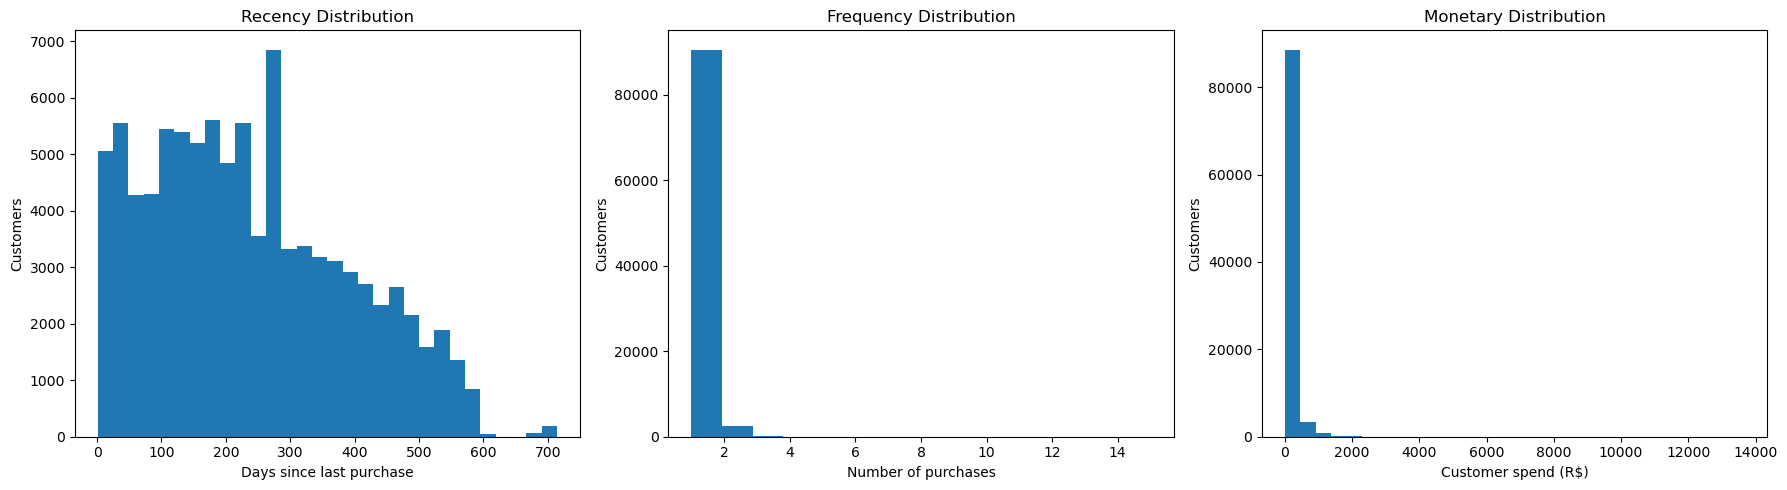

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm["recency"], bins=30)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")
axes[0].set_ylabel("Customers")

axes[1].hist(rfm["frequency"], bins=15)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of purchases")
axes[1].set_ylabel("Customers")

axes[2].hist(rfm["monetary"], bins=30)
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Customer spend (R$)")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.show()

In [92]:
import numpy as np

rfm_model = rfm.copy()

rfm_model["frequency_log"] = np.log1p(rfm_model["frequency"])
rfm_model["monetary_log"] = np.log1p(rfm_model["monetary"])

print(rfm_model[[
    "recency",
    "frequency",
    "monetary",
    "frequency_log",
    "monetary_log"
]].describe())

            recency     frequency      monetary  frequency_log  monetary_log
count  93358.000000  93358.000000  93358.000000   93358.000000  93358.000000
mean     237.941773      1.033420    165.168210       0.706198      4.728929
std      152.591453      0.209097    226.292101       0.076683      0.808388
min        1.000000      1.000000      9.590000       0.693147      2.359910
25%      114.000000      1.000000     63.010000       0.693147      4.159039
50%      219.000000      1.000000    107.780000       0.693147      4.689327
75%      346.000000      1.000000    182.510000       0.693147      5.212269
max      714.000000     15.000000  13664.080000       2.772589      9.522599


In [93]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm_model[
    ["recency", "frequency_log", "monetary_log"]
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaled shape:", rfm_scaled.shape)

print("\nMeans:")
print(rfm_scaled.mean(axis=0))

print("\nStandard deviations:")
print(rfm_scaled.std(axis=0))

Scaled shape: (93358, 3)

Means:
[-2.34417150e-17 -4.91971577e-16  3.08091111e-16]

Standard deviations:
[1. 1. 1.]


In [94]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use a representative sample for silhouette evaluation
sample_size = 10000

sample_indices = np.random.default_rng(42).choice(
    len(rfm_scaled),
    size=sample_size,
    replace=False
)

rfm_sample = rfm_scaled[sample_indices]

k_values = range(2, 9)
results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(rfm_sample)
    
    score = silhouette_score(
        rfm_sample,
        labels
    )
    
    results.append({
        "k": k,
        "silhouette_score": score
    })

k_results = pd.DataFrame(results)

print(k_results)

   k  silhouette_score
0  2          0.709455
1  3          0.357068
2  4          0.365042
3  5          0.352382
4  6          0.344569
5  7          0.355858
6  8          0.357114


In [95]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm_model["cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm_model["cluster"].value_counts().sort_index())

cluster
0     2801
1    90557
Name: count, dtype: int64


In [96]:
cluster_profile = (
    rfm_model
    .groupby("cluster")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        median_recency=("recency", "median"),
        median_frequency=("frequency", "median"),
        median_monetary=("monetary", "median")
    )
    .round(2)
)

cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,median_recency,median_frequency,median_monetary
cluster,,,,,,,
0,2801,220.29,2.11,308.53,199.0,2.0,225.55
1,90557,238.49,1.00,160.73,219.0,1.0,105.38


In [97]:
cluster_impact = (
    rfm_model
    .groupby("cluster")
    .agg(
        customers=("customer_unique_id", "count"),
        total_spend=("monetary", "sum"),
        avg_spend=("monetary", "mean")
    )
)

cluster_impact["customer_share_%"] = (
    cluster_impact["customers"]
    / cluster_impact["customers"].sum()
    * 100
)

cluster_impact["spend_share_%"] = (
    cluster_impact["total_spend"]
    / cluster_impact["total_spend"].sum()
    * 100
)

cluster_impact.round(2)

,customers,total_spend,avg_spend,customer_share_%,spend_share_%
cluster,,,,,
0,2801,864187.46,308.53,3.0,5.6
1,90557,14555586.29,160.73,97.0,94.4


In [98]:
print("TRADITIONAL RFM SEGMENTATION")

TRADITIONAL RFM SEGMENTATION


In [99]:
rfm_scored = rfm.copy()

# Recency: lower days = better score
rfm_scored["R_score"] = pd.qcut(
    rfm_scored["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

# Frequency: more purchases = better score
rfm_scored["F_score"] = pd.qcut(
    rfm_scored["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary: higher spend = better score
rfm_scored["M_score"] = pd.qcut(
    rfm_scored["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

# Convert scores from categorical to integers
rfm_scored[["R_score", "F_score", "M_score"]] = (
    rfm_scored[["R_score", "F_score", "M_score"]]
    .astype(int)
)

# Overall RFM score
rfm_scored["RFM_score"] = (
    rfm_scored["R_score"]
    + rfm_scored["F_score"]
    + rfm_scored["M_score"]
)

print(rfm_scored.head())

print("\nRFM score distribution:")
print(rfm_scored["RFM_score"].value_counts().sort_index())

                 customer_unique_id  recency  frequency  monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   

   F_score  M_score  RFM_score  
0        1        4          9  
1        1        1          6  
2        1        2          4  
3        1        1          4  
4        1        4          7  

RFM score distribution:
RFM_score
3       799
4      2363
5      4690
6      7583
7     11084
8     13319
9     13979
10    13143
11    10904
12     7461
13     4594
14     2439
15     1000
Name: count, dtype: int64


In [100]:
def assign_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal / High Value"
    elif r >= 4 and m >= 3:
        return "Recent Potential"
    elif r <= 2 and f >= 2:
        return "At Risk"
    elif r <= 2:
        return "Inactive"
    else:
        return "Needs Development"

rfm_scored["segment"] = rfm_scored.apply(assign_segment, axis=1)

print(
    rfm_scored["segment"]
    .value_counts()
)

segment
At Risk               29733
Needs Development     26318
Loyal / High Value    14210
Recent Potential       9117
Inactive               7483
Champions              6497
Name: count, dtype: int64


In [101]:
segment_profile = (
    rfm_scored
    .groupby("segment")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        median_recency=("recency", "median"),
        median_monetary=("monetary", "median")
    )
    .sort_values("avg_monetary", ascending=False)
    .round(2)
)

segment_profile

,customers,avg_recency,avg_frequency,avg_monetary,median_recency,median_monetary
segment,,,,,,
Champions,6497,91.11,1.18,311.99,91.0,211.78
Recent Potential,9117,90.95,1.00,233.29,93.0,160.79
Loyal / High Value,14210,153.25,1.05,207.08,170.0,137.97
At Risk,29733,394.57,1.04,165.96,382.0,106.16
Inactive,7483,396.72,1.00,162.82,386.0,104.28
Needs Development,26318,148.74,1.00,82.47,163.0,60.85


In [102]:
comparison = pd.crosstab(
    rfm_scored["segment"],
    rfm_model["cluster"],
    normalize="index"
) * 100

comparison.round(2)

cluster,0,1
segment,,
At Risk,3.32,96.68
Champions,15.24,84.76
Inactive,0.00,100.00
Loyal / High Value,5.08,94.92
Needs Development,0.38,99.62
Recent Potential,0.00,100.00


In [103]:
import sqlite3

# Create a SQLite database in your project folder
db_path = extract_folder / "olist_analysis.db"

conn = sqlite3.connect(db_path)

# Load each dataframe into SQLite
for table_name, df in dfs.items():
    df.to_sql(
        table_name,
        conn,
        if_exists="replace",
        index=False
    )

print("Database created at:")
print(db_path)

print("\nTables loaded:")
print(list(dfs.keys()))

Database created at:
olist_excel\olist_analysis.db

Tables loaded:
['customers', 'geolocation', 'orders', 'order_items', 'payments', 'reviews', 'products', 'sellers', 'category_translation', 'geo_lookup']


In [104]:
query = """
SELECT
    order_status,
    COUNT(*) AS order_count
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
"""

sql_result = pd.read_sql_query(query, conn)

sql_result

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [105]:
query = """
SELECT
    o.order_status,
    COUNT(DISTINCT o.order_id) AS order_count,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_order_value
FROM orders o
LEFT JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY o.order_status
ORDER BY total_order_value DESC;
"""

sql_result = pd.read_sql_query(query, conn)

sql_result

,order_status,order_count,total_order_value
0,delivered,96478,15419773.75
1,shipped,1107,177129.34
2,canceled,625,105885.72
3,processing,301,69394.11
4,invoiced,314,68988.75
5,unavailable,609,2140.49
6,approved,2,241.08
7,created,5,NaN


In [106]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS purchase_month,
    COUNT(DISTINCT o.order_id) AS delivered_orders,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS order_value
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY purchase_month
ORDER BY purchase_month;
"""

sql_monthly = pd.read_sql_query(query, conn)

sql_monthly

,purchase_month,delivered_orders,order_value
0,2016-09,1,143.46
1,2016-10,265,46490.66
2,2016-12,1,19.62
3,2017-01,750,127482.37
4,2017-02,1653,271239.32
5,2017-03,2546,414330.95
6,2017-04,2303,390812.40
7,2017-05,3546,566851.40
8,2017-06,3135,490050.37
9,2017-07,3872,566299.08


In [107]:
query = """
WITH customer_spend AS (
    SELECT
        c.customer_unique_id,
        c.customer_state,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS total_spend
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY
        c.customer_unique_id,
        c.customer_state
),

ranked_customers AS (
    SELECT
        customer_unique_id,
        customer_state,
        total_spend,
        ROW_NUMBER() OVER (
            PARTITION BY customer_state
            ORDER BY total_spend DESC
        ) AS state_rank
    FROM customer_spend
)

SELECT *
FROM ranked_customers
WHERE state_rank <= 3
ORDER BY customer_state, state_rank;
"""

top_customers_by_state = pd.read_sql_query(query, conn)

top_customers_by_state

,customer_unique_id,customer_state,total_spend,state_rank
0,62a459e5629b03dd73134964df732077,AC,1251.70,1
1,086d6b5b5ba195a91aa0a6ec8e75d1a4,AC,995.18,2
2,3947ca729a860c522a64a49d762baada,AC,905.93,3
3,03adb96012772d4374285b6a701f3da9,AL,2269.98,1
4,9b661514ad84d0489ac73d9e24cbf169,AL,1942.00,2
...,...,...,...,...
76,eebb5dda148d3893cdaf5b5ca3040ccb,SP,4764.34,2
77,edde2314c6c30e864a128ac95d6b2112,SP,4513.32,3
78,81d8bf17c9e450228efeedd2603edfaa,TO,2784.16,1
79,92ce8d58d57d7a8f8b2d5ca4b9810b64,TO,2094.44,2


In [108]:
query = """
WITH customer_spend AS (
    SELECT
        c.customer_unique_id,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS total_spend
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

ranked_spend AS (
    SELECT
        customer_unique_id,
        total_spend,
        SUM(total_spend) OVER (
            ORDER BY total_spend DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_spend,
        SUM(total_spend) OVER () AS total_spend_all_customers
    FROM customer_spend
)

SELECT
    customer_unique_id,
    total_spend,
    ROUND(
        cumulative_spend / total_spend_all_customers * 100,
        2
    ) AS cumulative_spend_percentage
FROM ranked_spend
ORDER BY total_spend DESC
LIMIT 20;
"""

pareto_top20 = pd.read_sql_query(query, conn)

pareto_top20

,customer_unique_id,total_spend,cumulative_spend_percentage
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,0.09
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,0.14
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,0.18
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31,0.23
4,459bef486812aa25204be022145caa62,6922.21,0.27
5,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,0.32
6,4007669dec559734d6f53e029e360987,6081.54,0.36
7,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,0.39
8,48e1ac109decbb87765a3eade6854098,4681.78,0.42
9,c8460e4251689ba205045f3ea17884a1,4655.88,0.45


In [109]:
query = """
WITH customer_spend AS (
    SELECT
        c.customer_unique_id,
        SUM(oi.price + oi.freight_value) AS total_spend
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

ranked_customers AS (
    SELECT
        customer_unique_id,
        total_spend,
        ROW_NUMBER() OVER (
            ORDER BY total_spend DESC
        ) AS customer_rank,
        COUNT(*) OVER () AS total_customers
    FROM customer_spend
)

SELECT
    CASE
        WHEN customer_rank <= total_customers * 0.01 THEN 'Top 1%'
        WHEN customer_rank <= total_customers * 0.05 THEN 'Top 5%'
        WHEN customer_rank <= total_customers * 0.10 THEN 'Top 10%'
        WHEN customer_rank <= total_customers * 0.20 THEN 'Top 20%'
        ELSE 'Bottom 80%'
    END AS customer_group,
    COUNT(*) AS customers,
    ROUND(SUM(total_spend), 2) AS total_spend,
    ROUND(
        SUM(total_spend) /
        (SELECT SUM(total_spend) FROM customer_spend) * 100,
        2
    ) AS spend_share_percentage
FROM ranked_customers
GROUP BY customer_group
ORDER BY
    CASE customer_group
        WHEN 'Top 1%' THEN 1
        WHEN 'Top 5%' THEN 2
        WHEN 'Top 10%' THEN 3
        WHEN 'Top 20%' THEN 4
        ELSE 5
    END;
"""

pareto_buckets = pd.read_sql_query(query, conn)

pareto_buckets

,customer_group,customers,total_spend,spend_share_percentage
0,Top 1%,933,1594900.61,10.34
1,Top 5%,3734,2536696.13,16.45
2,Top 10%,4668,1766618.71,11.46
3,Top 20%,9336,2355125.62,15.27
4,Bottom 80%,74687,7166432.68,46.48


In [110]:
query = """
WITH customer_spend AS (
    SELECT
        c.customer_unique_id,
        SUM(oi.price + oi.freight_value) AS total_spend
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

ranked_customers AS (
    SELECT
        customer_unique_id,
        total_spend,
        ROW_NUMBER() OVER (
            ORDER BY total_spend DESC
        ) AS customer_rank,
        COUNT(*) OVER () AS total_customers
    FROM customer_spend
),

cumulative AS (
    SELECT
        customer_rank,
        total_customers,
        total_spend,
        SUM(total_spend) OVER (
            ORDER BY customer_rank
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_spend,
        SUM(total_spend) OVER () AS total_spend_all
    FROM ranked_customers
)

SELECT
    'Top 1%' AS customer_group,
    COUNT(*) AS customers,
    ROUND(MAX(cumulative_spend) / MAX(total_spend_all) * 100, 2)
        AS cumulative_spend_share
FROM cumulative
WHERE customer_rank <= total_customers * 0.01

UNION ALL

SELECT
    'Top 5%',
    COUNT(*),
    ROUND(MAX(cumulative_spend) / MAX(total_spend_all) * 100, 2)
FROM cumulative
WHERE customer_rank <= total_customers * 0.05

UNION ALL

SELECT
    'Top 10%',
    COUNT(*),
    ROUND(MAX(cumulative_spend) / MAX(total_spend_all) * 100, 2)
FROM cumulative
WHERE customer_rank <= total_customers * 0.10

UNION ALL

SELECT
    'Top 20%',
    COUNT(*),
    ROUND(MAX(cumulative_spend) / MAX(total_spend_all) * 100, 2)
FROM cumulative
WHERE customer_rank <= total_customers * 0.20;
"""

pareto_correct = pd.read_sql_query(query, conn)

pareto_correct

,customer_group,customers,cumulative_spend_share
0,Top 1%,933,10.34
1,Top 5%,4667,26.79
2,Top 10%,9335,38.25
3,Top 20%,18671,53.52


In [111]:
query = """
SELECT
    p.product_category_english AS category,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_order_value,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(r.review_id) AS review_count
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN reviews r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY p.product_category_english
HAVING COUNT(DISTINCT o.order_id) >= 100
ORDER BY total_order_value DESC;
"""

category_analysis = pd.read_sql_query(query, conn)
category_analysis

,category,orders,total_order_value,avg_review_score,review_count
0,health_beauty,8647,1417268.99,4.19,9456
1,watches_gifts,5495,1265552.91,4.07,5825
2,bed_bath_table,9272,1241489.78,3.92,10985
3,sports_leisure,7530,1124637.43,4.17,8436
4,computers_accessories,6530,1041314.27,3.98,7672
5,furniture_decor,6307,888357.07,3.95,8159
6,housewares,5743,761055.43,4.11,6780
7,cool_stuff,3559,693721.94,4.19,3698
8,auto,3810,671019.97,4.12,4117
9,garden_tools,3448,568573.01,4.08,4254


In [112]:
query = """
WITH category_orders AS (
    SELECT DISTINCT
        o.order_id,
        p.product_category_english AS category
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'delivered'
),

order_review AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score
    FROM reviews
    GROUP BY order_id
)

SELECT
    co.category,
    COUNT(DISTINCT co.order_id) AS orders,
    ROUND(AVG(orv.review_score), 2) AS avg_review_score,
    COUNT(orv.review_score) AS reviewed_orders
FROM category_orders co
LEFT JOIN order_review orv
    ON co.order_id = orv.order_id
GROUP BY co.category
HAVING COUNT(DISTINCT co.order_id) >= 100
ORDER BY avg_review_score ASC;
"""

category_satisfaction = pd.read_sql_query(query, conn)
category_satisfaction

,category,orders,avg_review_score,reviewed_orders
0,office_furniture,1254,3.64,1244
1,fashion_male_clothing,106,3.82,105
2,audio,348,3.84,345
3,home_confort,392,3.89,390
4,construction_tools_safety,159,3.97,158
5,fixed_telephony,212,3.97,209
6,home_construction,483,3.99,481
7,bed_bath_table,9272,4.00,9177
8,Unknown / Unclassified,1392,4.01,1382
9,fashion_underwear_beach,117,4.01,116


In [113]:
query = """
WITH order_review AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score
    FROM reviews
    GROUP BY order_id
),

delivery AS (
    SELECT
        o.order_id,
        JULIANDAY(o.order_delivered_customer_date)
        - JULIANDAY(o.order_estimated_delivery_date) AS delivery_difference_days,
        r.review_score
    FROM orders o
    LEFT JOIN order_review r
        ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
)

SELECT
    CASE
        WHEN delivery_difference_days <= 0
            THEN 'Early / On Time'
        WHEN delivery_difference_days <= 3
            THEN '1-3 Days Late'
        WHEN delivery_difference_days <= 7
            THEN '4-7 Days Late'
        ELSE '8+ Days Late'
    END AS delivery_group,
    COUNT(*) AS orders,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    COUNT(review_score) AS reviewed_orders
FROM delivery
GROUP BY delivery_group
ORDER BY
    CASE delivery_group
        WHEN 'Early / On Time' THEN 1
        WHEN '1-3 Days Late' THEN 2
        WHEN '4-7 Days Late' THEN 3
        WHEN '8+ Days Late' THEN 4
    END;
"""

delivery_satisfaction = pd.read_sql_query(query, conn)
delivery_satisfaction

,delivery_group,orders,avg_review_score,reviewed_orders
0,Early / On Time,88644,4.29,88163
1,1-3 Days Late,2662,3.77,2636
2,4-7 Days Late,1819,2.32,1773
3,8+ Days Late,3345,1.73,3252


In [114]:
query = """
WITH category_orders AS (
    SELECT DISTINCT
        o.order_id,
        p.product_category_english AS category,
        JULIANDAY(o.order_delivered_customer_date)
        - JULIANDAY(o.order_estimated_delivery_date) AS delivery_difference_days
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
)

SELECT
    category,
    COUNT(*) AS orders,
    ROUND(AVG(delivery_difference_days), 2) AS avg_delivery_difference_days,
    ROUND(
        100.0 * SUM(
            CASE WHEN delivery_difference_days > 0 THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS late_delivery_rate
FROM category_orders
GROUP BY category
HAVING COUNT(*) >= 100
ORDER BY late_delivery_rate DESC;
"""

category_delivery = pd.read_sql_query(query, conn)
category_delivery

,category,orders,avg_delivery_difference_days,late_delivery_rate
0,audio,348,-9.36,12.93
1,fashion_underwear_beach,117,-9.78,12.82
2,books_technical,256,-10.62,10.94
3,home_confort,392,-9.06,10.46
4,food,441,-9.12,9.98
5,electronics,2517,-10.31,9.81
6,christmas_supplies,125,-11.46,9.60
7,baby,2809,-10.79,9.18
8,office_furniture,1254,-11.13,9.17
9,Unknown / Unclassified,1392,-10.70,9.12


In [115]:
query = """
WITH seller_orders AS (
    SELECT DISTINCT
        oi.seller_id,
        o.order_id,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
),

seller_reviews AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score
    FROM reviews
    GROUP BY order_id
),

seller_sales AS (
    SELECT
        seller_id,
        SUM(price + freight_value) AS sales
    FROM order_items
    GROUP BY seller_id
)

SELECT
    so.seller_id,
    COUNT(*) AS delivered_orders,
    ROUND(ss.sales, 2) AS sales,
    ROUND(AVG(sr.review_score), 2) AS avg_review_score,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN JULIANDAY(so.order_delivered_customer_date)
                   > JULIANDAY(so.order_estimated_delivery_date)
                THEN 1 ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS late_delivery_rate
FROM seller_orders so
LEFT JOIN seller_reviews sr
    ON so.order_id = sr.order_id
JOIN seller_sales ss
    ON so.seller_id = ss.seller_id
GROUP BY so.seller_id
HAVING COUNT(*) >= 100
ORDER BY late_delivery_rate DESC;
"""

seller_analysis = pd.read_sql_query(query, conn)
seller_analysis

,seller_id,delivered_orders,sales,avg_review_score,late_delivery_rate
0,06a2c3af7b3aee5d69171b0e14f0ee87,389,48550.24,4.01,23.14
1,1ca7077d890b907f89be8c954a02686a,108,15001.43,2.39,22.22
2,88460e8ebdecbfecb5f9601833981930,246,36543.10,3.44,19.51
3,e5a3438891c0bfdb9394643f95273d8e,216,11112.62,4.00,18.52
4,cd68562d3f44870c08922d380acae552,122,20777.19,4.02,18.03
...,...,...,...,...,...
205,229c3efbfb0ea2058de4ccdfbc3d784a,118,18106.57,3.62,1.69
206,12b9676b00f60f3b700e83af21824c0e,133,30342.69,4.54,1.50
207,8c16d1f32a54d92897cc437244442e1b,108,7754.67,4.36,0.93
208,0bae85eb84b9fb3bd773911e89288d54,136,10406.40,4.29,0.74


In [116]:
from sklearn.preprocessing import MinMaxScaler

seller_risk = seller_analysis.copy()

# Convert each metric to a 0–1 scale
scaler = MinMaxScaler()

seller_risk[[
    "late_risk",
    "review_risk",
    "sales_exposure"
]] = scaler.fit_transform(
    seller_risk[
        ["late_delivery_rate", "avg_review_score", "sales"]
    ]
)

# Reverse review score: lower rating = higher risk
seller_risk["review_risk"] = 1 - seller_risk["review_risk"]

seller_risk[[
    "seller_id",
    "delivered_orders",
    "sales",
    "avg_review_score",
    "late_delivery_rate",
    "late_risk",
    "review_risk",
    "sales_exposure"
]].head()

,seller_id,delivered_orders,sales,avg_review_score,late_delivery_rate,late_risk,review_risk,sales_exposure
0,06a2c3af7b3aee5d69171b0e14f0ee87,389,48550.24,4.01,23.14,1.000000,0.280000,0.179501
1,1ca7077d890b907f89be8c954a02686a,108,15001.43,2.39,22.22,0.960242,1.000000,0.042614
2,88460e8ebdecbfecb5f9601833981930,246,36543.10,3.44,19.51,0.843129,0.533333,0.130509
3,e5a3438891c0bfdb9394643f95273d8e,216,11112.62,4.00,18.52,0.800346,0.284444,0.026747
4,cd68562d3f44870c08922d380acae552,122,20777.19,4.02,18.03,0.779170,0.275556,0.066180


In [117]:
seller_risk["risk_score"] = (
    0.40 * seller_risk["late_risk"]
    + 0.40 * seller_risk["review_risk"]
    + 0.20 * seller_risk["sales_exposure"]
)

seller_risk = seller_risk.sort_values(
    "risk_score",
    ascending=False
)

seller_risk[
    [
        "seller_id",
        "delivered_orders",
        "sales",
        "avg_review_score",
        "late_delivery_rate",
        "risk_score"
    ]
].head(10)

,seller_id,delivered_orders,sales,avg_review_score,late_delivery_rate,risk_score
1,1ca7077d890b907f89be8c954a02686a,108,15001.43,2.39,22.22,0.792620
14,2eb70248d66e0e3ef83659f71b244378,187,45860.10,2.79,13.90,0.602870
2,88460e8ebdecbfecb5f9601833981930,246,36543.10,3.44,19.51,0.576687
57,7c67e1448b00f6e969d365cea6b010ab,973,239536.44,3.50,10.07,0.568492
0,06a2c3af7b3aee5d69171b0e14f0ee87,389,48550.24,4.01,23.14,0.547900
36,4a3ca9315b744ce9f8e9374361493884,1772,235539.96,3.85,11.00,0.519084
31,4869f7a5dfa277a7dca6462dcf3b52b2,1124,249640.70,4.15,11.57,0.487111
5,8160255418d5aaa7dbdc9f4c64ebda44,380,54871.50,3.95,16.58,0.450329
15,b2479f944e1b90cf8a5de1bbfde284d6,101,6992.22,3.50,13.86,0.444239
3,e5a3438891c0bfdb9394643f95273d8e,216,11112.62,4.00,18.52,0.439265


In [118]:
from scipy.stats import spearmanr

query = """
SELECT
    JULIANDAY(o.order_delivered_customer_date)
    - JULIANDAY(o.order_estimated_delivery_date) AS delivery_difference_days,
    r.review_score
FROM orders o
JOIN reviews r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL;
"""

delay_review = pd.read_sql_query(query, conn).dropna()

correlation, p_value = spearmanr(
    delay_review["delivery_difference_days"],
    delay_review["review_score"]
)

print(f"Spearman correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Observations: {len(delay_review):,}")

Spearman correlation: -0.1757
P-value: 0.0000e+00
Observations: 96,353


In [119]:
print("CHURN")

CHURN


In [120]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_purchase_timestamp,
        LAG(o.order_purchase_timestamp) OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp
        ) AS previous_purchase
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
)

SELECT
    COUNT(*) AS repeat_purchases,
    ROUND(
        AVG(
            JULIANDAY(order_purchase_timestamp)
            - JULIANDAY(previous_purchase)
        ),
        2
    ) AS avg_days_between_purchases,
    ROUND(
        MIN(
            JULIANDAY(order_purchase_timestamp)
            - JULIANDAY(previous_purchase)
        ),
        2
    ) AS min_days_between,
    ROUND(
        MAX(
            JULIANDAY(order_purchase_timestamp)
            - JULIANDAY(previous_purchase)
        ),
        2
    ) AS max_days_between
FROM customer_orders
WHERE previous_purchase IS NOT NULL;
"""

repurchase_intervals = pd.read_sql_query(query, conn)
repurchase_intervals

,repeat_purchases,avg_days_between_purchases,min_days_between,max_days_between
0,3120,79.15,0.0,608.98


In [121]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_purchase_timestamp,
        LAG(o.order_purchase_timestamp) OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp
        ) AS previous_purchase
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
),

intervals AS (
    SELECT
        JULIANDAY(order_purchase_timestamp)
        - JULIANDAY(previous_purchase) AS days_between
    FROM customer_orders
    WHERE previous_purchase IS NOT NULL
)

SELECT
    COUNT(*) AS repeat_purchases,
    SUM(CASE WHEN days_between <= 30 THEN 1 ELSE 0 END) AS within_30_days,
    SUM(CASE WHEN days_between <= 60 THEN 1 ELSE 0 END) AS within_60_days,
    SUM(CASE WHEN days_between <= 90 THEN 1 ELSE 0 END) AS within_90_days,
    SUM(CASE WHEN days_between <= 180 THEN 1 ELSE 0 END) AS within_180_days,
    SUM(CASE WHEN days_between <= 365 THEN 1 ELSE 0 END) AS within_365_days
FROM intervals;
"""

repurchase_distribution = pd.read_sql_query(query, conn)

repurchase_distribution

,repeat_purchases,within_30_days,within_60_days,within_90_days,within_180_days,within_365_days
0,3120,1564,1923,2148,2605,3036


In [122]:
query = """
WITH delivered_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
),

dataset_info AS (
    SELECT
        MAX(order_purchase_timestamp) AS dataset_end
    FROM delivered_orders
),

customer_last_purchase AS (
    SELECT
        customer_unique_id,
        MAX(order_purchase_timestamp) AS last_purchase
    FROM delivered_orders
    GROUP BY customer_unique_id
)

SELECT
    COUNT(*) AS eligible_customers,
    MIN(last_purchase) AS earliest_last_purchase,
    MAX(last_purchase) AS latest_eligible_purchase,
    (SELECT dataset_end FROM dataset_info) AS dataset_end,
    DATE(
        (SELECT dataset_end FROM dataset_info),
        '-180 days'
    ) AS churn_cutoff
FROM customer_last_purchase
WHERE last_purchase <= DATE(
    (SELECT dataset_end FROM dataset_info),
    '-180 days'
);
"""

churn_cutoff = pd.read_sql_query(query, conn)
churn_cutoff

,eligible_customers,earliest_last_purchase,latest_eligible_purchase,dataset_end,churn_cutoff
0,55132,2016-09-15 12:16:38,2018-03-01 23:56:42,2018-08-29 15:00:37,2018-03-02


In [123]:
query = """
WITH delivered_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
),

customer_last_purchase AS (
    SELECT
        customer_unique_id,
        MAX(order_purchase_timestamp) AS last_purchase
    FROM delivered_orders
    GROUP BY customer_unique_id
),

dataset_info AS (
    SELECT
        MAX(order_purchase_timestamp) AS dataset_end
    FROM delivered_orders
),

eligible_customers AS (
    SELECT
        clp.customer_unique_id,
        clp.last_purchase
    FROM customer_last_purchase clp
    CROSS JOIN dataset_info di
    WHERE clp.last_purchase <= DATE(di.dataset_end, '-180 days')
),

future_purchases AS (
    SELECT
        ec.customer_unique_id,
        COUNT(d.order_id) AS future_orders
    FROM eligible_customers ec
    LEFT JOIN delivered_orders d
        ON ec.customer_unique_id = d.customer_unique_id
        AND d.order_purchase_timestamp > ec.last_purchase
        AND d.order_purchase_timestamp <= DATETIME(
            ec.last_purchase,
            '+180 days'
        )
    GROUP BY ec.customer_unique_id
)

SELECT
    ec.customer_unique_id,
    ec.last_purchase,
    fp.future_orders,
    CASE
        WHEN fp.future_orders = 0 THEN 1
        ELSE 0
    END AS churn
FROM eligible_customers ec
JOIN future_purchases fp
    ON ec.customer_unique_id = fp.customer_unique_id;
"""

churn_labels = pd.read_sql_query(query, conn)

churn_labels.head()

,customer_unique_id,last_purchase,future_orders,churn
0,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,0,1
1,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,0,1
2,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,0,1
3,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,0,1
4,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,0,1


In [124]:
churn_labels["churn"].value_counts(normalize=False).rename("customers")

churn
1    55132
Name: customers, dtype: int64

In [125]:
churn_labels["churn"].value_counts(normalize=True).mul(100).round(2).rename("percentage")

churn
1    100.0
Name: percentage, dtype: float64

In [126]:
query = """
WITH delivered_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
),

customer_last_purchase AS (
    SELECT
        customer_unique_id,
        MAX(order_purchase_timestamp) AS last_purchase
    FROM delivered_orders
    GROUP BY customer_unique_id
),

dataset_info AS (
    SELECT
        MAX(order_purchase_timestamp) AS dataset_end
    FROM delivered_orders
),

eligible_customers AS (
    SELECT
        clp.customer_unique_id,
        clp.last_purchase
    FROM customer_last_purchase clp
    CROSS JOIN dataset_info di
    WHERE JULIANDAY(di.dataset_end)
          - JULIANDAY(clp.last_purchase) >= 180
),

future_purchases AS (
    SELECT
        ec.customer_unique_id,
        COUNT(d.order_id) AS future_orders
    FROM eligible_customers ec
    LEFT JOIN delivered_orders d
        ON ec.customer_unique_id = d.customer_unique_id
        AND JULIANDAY(d.order_purchase_timestamp)
            > JULIANDAY(ec.last_purchase)
        AND JULIANDAY(d.order_purchase_timestamp)
            <= JULIANDAY(ec.last_purchase) + 180
    GROUP BY ec.customer_unique_id
)

SELECT
    ec.customer_unique_id,
    ec.last_purchase,
    fp.future_orders,
    CASE
        WHEN fp.future_orders = 0 THEN 1
        ELSE 0
    END AS churn
FROM eligible_customers ec
JOIN future_purchases fp
    ON ec.customer_unique_id = fp.customer_unique_id;
"""

churn_labels = pd.read_sql_query(query, conn)

print("Customers:", len(churn_labels))
print("\nChurn distribution:")
print(churn_labels["churn"].value_counts())

print("\nChurn percentage:")
print(
    churn_labels["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Customers: 55252

Churn distribution:
churn
1    55252
Name: count, dtype: int64

Churn percentage:
churn
1    100.0
Name: proportion, dtype: float64


In [127]:
# Create delivery-delay target

ml_orders = dfs["orders"].copy()

# Keep only delivered orders with valid actual and estimated delivery dates
ml_orders = ml_orders[
    (ml_orders["order_status"] == "delivered") &
    (ml_orders["order_delivered_customer_date"].notna()) &
    (ml_orders["order_estimated_delivery_date"].notna())
].copy()

# Calculate delivery difference
ml_orders["delivery_difference_days"] = (
    ml_orders["order_delivered_customer_date"]
    - ml_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

# Target: 1 = Late, 0 = Early/On Time
ml_orders["late_delivery"] = (
    ml_orders["delivery_difference_days"] > 0
).astype(int)

print("ML dataset shape:", ml_orders.shape)

print("\nLate delivery distribution:")
print(ml_orders["late_delivery"].value_counts())

print("\nLate delivery percentage:")
print(
    ml_orders["late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ML dataset shape: (96470, 14)

Late delivery distribution:
late_delivery
0    88644
1     7826
Name: count, dtype: int64

Late delivery percentage:
late_delivery
0    91.89
1     8.11
Name: proportion, dtype: float64


In [128]:
# Build order-level features for delivery-delay prediction

# Start with the orders used for ML
features = ml_orders[
    [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_estimated_delivery_date"
    ]
].copy()

# Convert dates to datetime
features["order_purchase_timestamp"] = pd.to_datetime(
    features["order_purchase_timestamp"]
)
features["order_estimated_delivery_date"] = pd.to_datetime(
    features["order_estimated_delivery_date"]
)

# ---------------------------------------------------------
# 1. Order-item features
# ---------------------------------------------------------

items = dfs["order_items"].copy()

item_features = (
    items.groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        avg_item_price=("price", "mean"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

features = features.merge(
    item_features,
    on="order_id",
    how="left"
)

# ---------------------------------------------------------
# 2. Seller information
# ---------------------------------------------------------

seller_info = dfs["order_items"][
    ["order_id", "seller_id"]
].drop_duplicates("order_id")

seller_info = seller_info.merge(
    dfs["sellers"][
        ["seller_id", "seller_state"]
    ],
    on="seller_id",
    how="left"
)

features = features.merge(
    seller_info[["order_id", "seller_state"]],
    on="order_id",
    how="left"
)

# ---------------------------------------------------------
# 3. Customer information
# ---------------------------------------------------------

customer_info = dfs["customers"][
    ["customer_id", "customer_state"]
].drop_duplicates("customer_id")

features = features.merge(
    customer_info,
    on="customer_id",
    how="left"
)

# ---------------------------------------------------------
# 4. Time-based features
# ---------------------------------------------------------

features["purchase_year"] = (
    features["order_purchase_timestamp"].dt.year
)

features["purchase_month"] = (
    features["order_purchase_timestamp"].dt.month
)

features["purchase_dayofweek"] = (
    features["order_purchase_timestamp"].dt.dayofweek
)

features["purchase_hour"] = (
    features["order_purchase_timestamp"].dt.hour
)

# ---------------------------------------------------------
# 5. Shipping window available at order time
# ---------------------------------------------------------

features["estimated_delivery_days"] = (
    features["order_estimated_delivery_date"]
    - features["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# ---------------------------------------------------------
# Check the resulting dataset
# ---------------------------------------------------------

print("Feature dataset shape:", features.shape)

print("\nColumns:")
print(features.columns.tolist())

print("\nMissing values:")
print(features.isnull().sum())

print("\nFirst 5 rows:")
display(features.head())

Feature dataset shape: (96470, 17)

Columns:
['order_id', 'customer_id', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'total_items', 'total_price', 'total_freight', 'avg_item_price', 'unique_products', 'unique_sellers', 'seller_state', 'customer_state', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'estimated_delivery_days']

Missing values:
order_id                         0
customer_id                      0
order_purchase_timestamp         0
order_estimated_delivery_date    0
total_items                      0
total_price                      0
total_freight                    0
avg_item_price                   0
unique_products                  0
unique_sellers                   0
seller_state                     0
customer_state                   0
purchase_year                    0
purchase_month                   0
purchase_dayofweek               0
purchase_hour                    0
estimated_delivery_days          0
dtype: int64

Fir

,order_id,customer_id,order_purchase_timestamp,order_estimated_delivery_date,total_items,total_price,total_freight,avg_item_price,unique_products,unique_sellers,seller_state,customer_state,purchase_year,purchase_month,purchase_dayofweek,purchase_hour,estimated_delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-18,1,29.99,8.72,29.99,1,1,SP,SP,2017,10,0,10,15.544063
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-13,1,118.70,22.76,118.70,1,1,SP,BA,2018,7,1,20,19.137766
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-09-04,1,159.90,19.22,159.90,1,1,SP,GO,2018,8,2,8,26.639711
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-15,1,45.00,27.20,45.00,1,1,MG,RN,2017,11,5,19,26.188819
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-26,1,19.90,8.72,19.90,1,1,SP,SP,2018,2,1,21,12.112049


In [129]:
# Prepare features (X) and target (y)

# Target
y = ml_orders["late_delivery"]

# Remove IDs and raw date columns that should not be used as model inputs
X = features.drop(
    columns=[
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_estimated_delivery_date"
    ]
).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

X shape: (96470, 13)
y shape: (96470,)

Feature columns:
['total_items', 'total_price', 'total_freight', 'avg_item_price', 'unique_products', 'unique_sellers', 'seller_state', 'customer_state', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'estimated_delivery_days']

Target distribution:
late_delivery
0    88644
1     7826
Name: count, dtype: int64

Target percentage:
late_delivery
0    91.89
1     8.11
Name: proportion, dtype: float64


In [130]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_features = [
    "seller_state",
    "customer_state"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: (77176, 13)
Test set: (19294, 13)

Training target distribution:
late_delivery
0    0.9189
1    0.0811
Name: proportion, dtype: float64

Test target distribution:
late_delivery
0    0.9189
1    0.0811
Name: proportion, dtype: float64


In [131]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Build Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [132]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Identify feature types
categorical_features = [
    "seller_state",
    "customer_state"
]

numeric_features = [
    "total_items",
    "total_price",
    "total_freight",
    "avg_item_price",
    "unique_products",
    "unique_sellers",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "estimated_delivery_days"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor updated successfully.")
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Preprocessor updated successfully.
Numeric features: 11
Categorical features: 2


In [133]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Build Logistic Regression pipeline with updated preprocessing
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [134]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Make predictions
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
----------------------------------------
Accuracy : 0.6298
Precision: 0.1323
Recall   : 0.6409
F1 Score : 0.2193
ROC-AUC  : 0.6932

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.63      0.76     17729
           1       0.13      0.64      0.22      1565

    accuracy                           0.63     19294
   macro avg       0.54      0.63      0.49     19294
weighted avg       0.89      0.63      0.71     19294



In [135]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest pipeline
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [136]:
# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Performance")
print("-" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Performance
----------------------------------------
Accuracy : 0.8295
Precision: 0.2524
Recall   : 0.5617
F1 Score : 0.3483
ROC-AUC  : 0.7813

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90     17729
           1       0.25      0.56      0.35      1565

    accuracy                           0.83     19294
   macro avg       0.60      0.71      0.63     19294
weighted avg       0.90      0.83      0.86     19294



In [137]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use the probabilities already generated by Random Forest
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:

    predictions = (rf_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Accuracy,Precision,Recall,F1
0,0.2,0.1343,0.0851,0.9923,0.1568
1,0.3,0.3713,0.1077,0.9272,0.1930
2,0.4,0.6753,0.1657,0.7444,0.2711
3,0.5,0.8295,0.2524,0.5617,0.3483
4,0.6,0.8892,0.3345,0.3700,0.3513
5,0.7,0.9117,0.4109,0.2032,0.2719
6,0.8,0.9199,0.5820,0.0454,0.0842


In [138]:
# Final prediction threshold
final_threshold = 0.60

# Generate final predictions
final_predictions = (rf_prob >= final_threshold).astype(int)

# Create prediction dataframe
predictions = X_test.copy()

predictions["actual_late"] = y_test.values
predictions["late_probability"] = rf_prob
predictions["predicted_late"] = final_predictions

print("Final threshold:", final_threshold)

print("\nFinal prediction distribution:")
print(predictions["predicted_late"].value_counts())

print("\nFinal performance:")
print(f"Accuracy : {accuracy_score(y_test, final_predictions):.4f}")
print(f"Precision: {precision_score(y_test, final_predictions):.4f}")
print(f"Recall   : {recall_score(y_test, final_predictions):.4f}")
print(f"F1 Score : {f1_score(y_test, final_predictions):.4f}")

Final threshold: 0.6

Final prediction distribution:
predicted_late
0    17563
1     1731
Name: count, dtype: int64

Final performance:
Accuracy : 0.8892
Precision: 0.3345
Recall   : 0.3700
F1 Score : 0.3513


In [139]:
# Extract the trained Random Forest
rf_classifier = rf_model.named_steps["classifier"]

# Extract the fitted preprocessor
fitted_preprocessor = rf_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance
importances = rf_classifier.feature_importances_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 features:")
display(feature_importance.head(20))

Top 20 features:


,feature,importance
0,numeric__purchase_month,0.225913
1,numeric__estimated_delivery_days,0.194735
2,numeric__total_freight,0.095112
3,numeric__avg_item_price,0.064663
4,numeric__total_price,0.063167
5,categorical__customer_state_SP,0.045573
6,numeric__purchase_hour,0.045189
7,numeric__purchase_year,0.039387
8,categorical__customer_state_RJ,0.032467
9,numeric__purchase_dayofweek,0.032184


In [140]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Create dataframe
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

# Sort by importance
perm_df = perm_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

print("Permutation Importance:")
display(perm_df)

Permutation Importance:


,feature,importance_mean,importance_std
0,purchase_month,0.108421,0.003323
1,estimated_delivery_days,0.084662,0.002281
2,customer_state,0.081015,0.001500
3,purchase_year,0.036473,0.001614
4,seller_state,0.021283,0.002122
5,total_freight,0.019269,0.002220
6,purchase_dayofweek,0.001997,0.000549
7,total_items,0.001902,0.000630
8,unique_sellers,0.001862,0.000649
9,avg_item_price,0.001741,0.000835


Confusion Matrix:
[[16577  1152]
 [  986   579]]


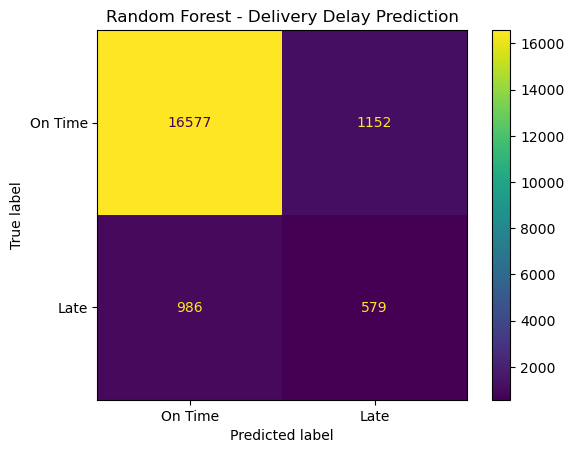

In [141]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix using final threshold of 0.60
cm = confusion_matrix(y_test, final_predictions)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On Time", "Late"]
)

disp.plot()
plt.title("Random Forest - Delivery Delay Prediction")
plt.show()

In [142]:
# Create final ML prediction dataset

predictions = X_test.copy()

# Add actual and predicted outcomes
predictions["actual_late"] = y_test.values
predictions["late_probability"] = rf_prob
predictions["predicted_late"] = final_predictions

# Create a business-friendly risk category
predictions["risk_category"] = pd.cut(
    predictions["late_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

print("Final ML dataset shape:", predictions.shape)

print("\nRisk category distribution:")
print(predictions["risk_category"].value_counts())

print("\nSample predictions:")
display(predictions.head(10))

Final ML dataset shape: (19294, 17)

Risk category distribution:
risk_category
Medium Risk    11737
Low Risk        5826
High Risk       1731
Name: count, dtype: int64

Sample predictions:


,total_items,total_price,total_freight,avg_item_price,unique_products,unique_sellers,seller_state,customer_state,purchase_year,purchase_month,purchase_dayofweek,purchase_hour,estimated_delivery_days,actual_late,late_probability,predicted_late,risk_category
61669,1,325.00,23.07,325.00,1,1,SP,MA,2018,2,5,20,25.138495,0,0.787928,1,High Risk
70878,1,129.90,15.66,129.90,1,1,RJ,SP,2018,1,1,16,23.302685,0,0.471391,0,Medium Risk
6622,2,276.00,26.62,138.00,2,1,SP,SP,2017,6,2,15,20.349201,0,0.298181,0,Low Risk
12575,1,28.90,14.52,28.90,1,1,SP,RJ,2017,4,3,13,21.453414,0,0.421420,0,Medium Risk
85114,1,104.90,43.14,104.90,1,1,MG,PA,2017,10,1,22,35.079387,0,0.403775,0,Medium Risk
40656,1,65.00,25.73,65.00,1,1,SC,MG,2017,6,4,1,31.941586,0,0.183857,0,Low Risk
14110,2,57.80,30.20,28.90,1,1,SC,PR,2017,11,5,0,24.988241,0,0.339451,0,Medium Risk
95851,1,28.00,8.27,28.00,1,1,SP,SP,2018,2,0,19,15.175255,0,0.368421,0,Medium Risk
36780,1,39.90,11.85,39.90,1,1,SP,SP,2017,12,4,16,25.305799,0,0.271866,0,Low Risk
16053,1,35.99,12.69,35.99,1,1,SP,SP,2017,7,1,9,26.594398,0,0.209527,0,Low Risk


In [143]:
# Add original identifiers back to the prediction dataset

predictions["order_id"] = features.loc[
    predictions.index,
    "order_id"
].values

predictions["customer_id"] = features.loc[
    predictions.index,
    "customer_id"
].values

# Move identifiers to the beginning
predictions = predictions[
    [
        "order_id",
        "customer_id",
        "total_items",
        "total_price",
        "total_freight",
        "avg_item_price",
        "unique_products",
        "unique_sellers",
        "seller_state",
        "customer_state",
        "purchase_year",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour",
        "estimated_delivery_days",
        "actual_late",
        "late_probability",
        "predicted_late",
        "risk_category"
    ]
]

print("Final prediction dataset shape:", predictions.shape)

print("\nColumns:")
print(predictions.columns.tolist())

print("\nSample:")
display(predictions.head())

Final prediction dataset shape: (19294, 19)

Columns:
['order_id', 'customer_id', 'total_items', 'total_price', 'total_freight', 'avg_item_price', 'unique_products', 'unique_sellers', 'seller_state', 'customer_state', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'estimated_delivery_days', 'actual_late', 'late_probability', 'predicted_late', 'risk_category']

Sample:


,order_id,customer_id,total_items,total_price,total_freight,avg_item_price,unique_products,unique_sellers,seller_state,customer_state,purchase_year,purchase_month,purchase_dayofweek,purchase_hour,estimated_delivery_days,actual_late,late_probability,predicted_late,risk_category
61669,e713dc6c1f73c883bc8e42bff335eb8e,a9ccc267c0e5c32d1c1fd493dfd99fbe,1,325.0,23.07,325.0,1,1,SP,MA,2018,2,5,20,25.138495,0,0.787928,1,High Risk
70878,c52439e463e5cd80125600ab8ee93344,e2e763654987a355699fe26e00edf776,1,129.9,15.66,129.9,1,1,RJ,SP,2018,1,1,16,23.302685,0,0.471391,0,Medium Risk
6622,5f5d440ddcc70a0ba6f17804435ec791,898c1761bbffa916c3449f48099bdc32,2,276.0,26.62,138.0,2,1,SP,SP,2017,6,2,15,20.349201,0,0.298181,0,Low Risk
12575,119b654c77fbffcad6cdb07398506c93,a1674724305cdde2e900f8f50583f764,1,28.9,14.52,28.9,1,1,SP,RJ,2017,4,3,13,21.453414,0,0.421420,0,Medium Risk
85114,4f8aa330d043e9db140284db7a6c3359,cd4260e37ba9618a2aca53bd78ca9a8d,1,104.9,43.14,104.9,1,1,MG,PA,2017,10,1,22,35.079387,0,0.403775,0,Medium Risk


In [144]:
# Export final ML predictions for Power BI

output_file = "delivery_delay_predictions.csv"

predictions.to_csv(
    output_file,
    index=False
)

print(f"File exported successfully: {output_file}")
print(f"Rows exported: {len(predictions):,}")
print(f"Columns exported: {len(predictions.columns)}")

File exported successfully: delivery_delay_predictions.csv
Rows exported: 19,294
Columns exported: 19


In [145]:
import os

print("Notebook working directory:")
print(os.getcwd())

print("\nExported file:")
print(os.path.abspath("delivery_delay_predictions.csv"))

print("\nFile exists:", os.path.exists("delivery_delay_predictions.csv"))

Notebook working directory:
C:\Users\shiva

Exported file:
C:\Users\shiva\delivery_delay_predictions.csv

File exists: True
